# Example: Applying Distributions to Equity and Bond Returns

Notebooks 01–02 introduced population distributions and dependence. Notebooks 03–04 developed inference and empirical descriptions, while Notebook 05 connected returns to loss risk. Here I apply those tools to observed equity and bond returns. The central question is whether a distribution selected from one period provides useful expectations about returns and losses in a subsequent period.

I first study SPY equity returns and AGG bond returns separately. For each asset, I describe the empirical distribution, estimate candidate parametric models on 2017–2022, and freeze their predictions before evaluating 2023–2025. I then fit a joint model to the paired observations and examine how its restrictions change the implied marginal predictions. The final comparison separates agreement about mean, dispersion and downside risk, rather than assuming that one description must be best for all three.

The likelihood calculations use the working framework $R_1,\ldots,R_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$, with unknown $\theta$. These are fixed unconditional distributions: they summarize pooled returns without using their temporal ordering. The time-series notebooks will examine what that ordering reveals about dependence and changing conditional risk.


In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.integrate import quad
from IPython.display import display, Markdown
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from finstats.nonparametric import empirical_cdf, empirical_quantile, qq_data
from finstats.risk import (
    historical_var, historical_es, gaussian_var, gaussian_es, student_t_var, student_t_es,
)
from finstats.multivariate import covariance_matrix, correlation, linear_combination_mean, linear_combination_variance
from finance_statistical_methods.returns.returns import simple_returns
from finance_statistical_methods.distributions.univariate import normal, student_t, laplace, skew_normal
from finstats.multivariate_fit import multivariate_t_mle
from finance_statistical_methods.distributions.univariate.fit_statistics import aic, bic
from finstats.multivariate_skew_normal import (
    multivariate_skew_normal_logpdf, multivariate_skew_normal_moments,
    multivariate_skew_normal_rvs, multivariate_skew_normal_mle,
)

## 1. Data and Return Construction

I use SPY, an S&P 500 equity ETF, and AGG, a broad US investment-grade bond ETF. These are fund proxies rather than the underlying indices. Both trade in USD, which avoids adding currency conversion to the dependence analysis.

The fixed 2017–2025 snapshots contain closing and distribution-adjusted closing prices. I calculate returns from the **adjusted** series, incorporating the provider's split and distribution adjustments. This is a total-return proxy, not an exact index total-return series. Fund expenses and tracking differences remain part of the observed fund performance. Sources, adjustment conventions and checksums are recorded in [the data documentation](../data/README.md).

I intersect price dates **before** calculating returns, so both assets have the same start and end points. No prices are interpolated or forward filled. For adjusted level $P_t^*$, the simple percentage return is

$$r_t=100\left(\frac{P_t^*}{P_{t-1}^*}-1\right).$$

Simple returns make fixed-weight aggregation exact. They differ from the log returns used in the course's original S&P 500 demonstration. An observation spans consecutive available trading dates, which can be several calendar days apart.

### Training and Out-of-Sample Evaluation

I use return endpoints through 2022-12-31 for estimation, and endpoints from 2023-01-01 onward for evaluation. The first out-of-sample return uses its actual preceding price, even when that price falls in December 2022. No return is omitted at the boundary.

Candidate models, fitted parameters, expected returns and loss thresholds are determined using the training observations. I select the working family by **training BIC**, with training AIC as a cross-check. I do not refit or switch families after examining the out-of-sample period. These are fixed unconditional distributional predictions, not predictions conditioned on the preceding return.

This is a retrospective out-of-sample check: the full period was inspected in the earlier draft. The revised fitting and selection calculations use training data only, but this is not a previously unseen live test.

The figure shows both complete realized return histories. Blue marks the in-sample estimation period and orange the out-of-sample evaluation period, with the same boundary for both assets.

,Missing levels before alignment
Equity (SPY),0
Bonds (AGG),0


2262 common price dates, 2261 paired returns
Price endpoints: 2017-01-03 to 2025-12-31
Intervals spanning more than one calendar day: 494
Training: 1509 returns, 2017-01-04 to 2022-12-30
Out-of-sample: 752 returns, 2023-01-03 to 2025-12-31


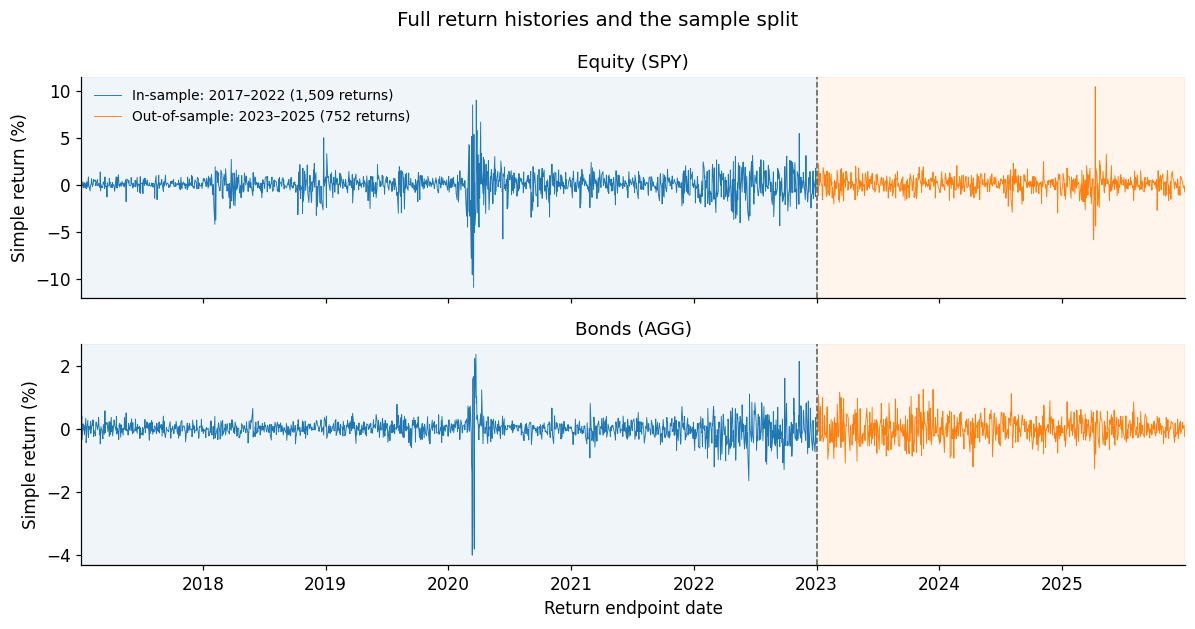

In [2]:
files = {"Equity (SPY)": "spy_adjusted_prices_2017_2025.csv",
         "Bonds (AGG)": "agg_adjusted_prices_2017_2025.csv"}
levels = {}
for name, filename in files.items():
    frame = pd.read_csv(repository / "data" / filename, parse_dates=["Date"]).set_index("Date")
    assert frame.index.is_unique and frame.index.is_monotonic_increasing
    levels[name] = frame["AdjustedClose"]
price_panel = pd.concat(levels, axis=1)
display(price_panel.isna().sum().rename("Missing levels before alignment").to_frame())
aligned_prices = price_panel.dropna()
returns = pd.DataFrame({name: 100*simple_returns(aligned_prices[name].to_numpy())
                        for name in files}, index=aligned_prices.index[1:])
equity = returns.iloc[:, 0].to_numpy()
bonds = returns.iloc[:, 1].to_numpy()
joint_values = returns.to_numpy()
print(f"{len(aligned_prices)} common price dates, {len(returns)} paired returns")
print(f"Price endpoints: {aligned_prices.index[0].date()} to {aligned_prices.index[-1].date()}")
print("Intervals spanning more than one calendar day:",
      int((aligned_prices.index.to_series().diff().dt.days > 1).sum()))
training = returns.loc[returns.index < "2023-01-01"].copy()
test_sample = returns.loc[returns.index >= "2023-01-01"].copy()
assert len(training)+len(test_sample) == len(returns)
assert training.index.max() < test_sample.index.min()
assert not training.index.intersection(test_sample.index).size
equity_train = training.iloc[:, 0].to_numpy()
equity_test = test_sample.iloc[:, 0].to_numpy()
bond_train = training.iloc[:, 1].to_numpy()
bond_test = test_sample.iloc[:, 1].to_numpy()
print(f"Training: {len(training)} returns, {training.index.min().date()} to {training.index.max().date()}")
print(f"Out-of-sample: {len(test_sample)} returns, {test_sample.index.min().date()} to {test_sample.index.max().date()}")
fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True)
split_date = pd.Timestamp("2023-01-01")
for ax, name in zip(axes, returns.columns):
    ax.axvspan(returns.index.min(), split_date, color="C0", alpha=.07)
    ax.axvspan(split_date, returns.index.max(), color="C1", alpha=.07)
    ax.plot(training.index, training[name], color="C0", linewidth=.6,
            label=f"In-sample: 2017–2022 ({len(training):,} returns)")
    ax.plot(test_sample.index, test_sample[name], color="C1", linewidth=.6,
            label=f"Out-of-sample: 2023–2025 ({len(test_sample):,} returns)")
    ax.axvline(split_date, color="0.35", linestyle="--", linewidth=1)
    ax.set(title=name, ylabel="Simple return (%)",
           xlim=(returns.index.min(), returns.index.max()))
axes[0].legend(loc="upper left", fontsize=9)
axes[1].set_xlabel("Return endpoint date")
fig.suptitle("Full return histories and the sample split", fontsize=13)
fig.tight_layout()
plt.show()

## 2. Univariate Example: Equity Returns

I first study SPY on its own, applying the distributions and risk measures developed in Notebooks 01–05. I describe the observed returns, estimate candidate models and compare their implied loss risk. All calculations before **Out-of-Sample Evaluation** use the 2017–2022 estimation period. I then freeze the estimates and assess them against 2023–2025.

### Empirical Distribution and Moments

The mean, sample variance with denominator $n-1$, skewness and raw kurtosis summarize the observations using the definitions from Notebook 01. These are empirical quantities, not known population moments.

The histogram, KDE and ECDF describe the pooled distribution, as in Notebook 04. Together they show concentration, dispersion and cumulative probabilities before imposing a parametric model.

,n,Mean (%),Variance (%²),SD (%),Skewness,Raw kurtosis
SPY,1509,0.0499,1.5661,1.2515,-0.5747,15.5305


Observations outside the density display [-5%, 5%]: 13


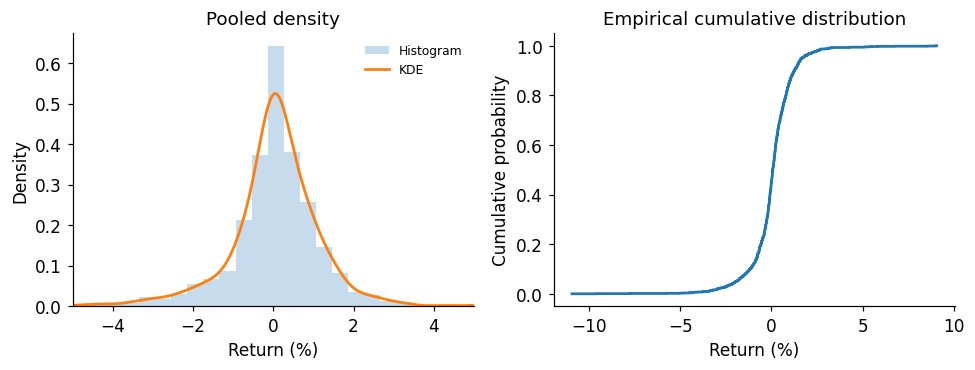

In [3]:
display(pd.DataFrame({"n": [len(equity_train)], "Mean (%)": [sample_mean(equity_train)],
    "Variance (%²)": [sample_variance(equity_train)], "SD (%)": [sample_standard_deviation(equity_train)],
    "Skewness": [sample_skewness(equity_train)], "Raw kurtosis": [sample_kurtosis(equity_train)]}, index=["SPY"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
grid = np.linspace(equity_train.min()-.5, equity_train.max()+.5, 1001)
axes[0].hist(equity_train, bins=50, density=True, alpha=.25, label="Histogram")
axes[0].plot(grid, stats.gaussian_kde(equity_train)(grid), label="KDE")
axes[0].set(title="Pooled density", xlabel="Return (%)", ylabel="Density", xlim=(-5,5))
print("Observations outside the density display [-5%, 5%]:", int((abs(equity_train)>5).sum()))
axes[0].legend(fontsize=8)
axes[1].step(np.sort(equity_train), empirical_cdf(equity_train)(np.sort(equity_train)), where="post")
axes[1].set(title="Empirical cumulative distribution", xlabel="Return (%)", ylabel="Cumulative probability")
fig.tight_layout()
plt.show()

### Parametric Models and Estimation

I fit the Gaussian, Student-t, Laplace and skew-normal models from Notebook 01 to the **same equity training sample** in percentage-point units. Under the working IID framework, the fitted parameters maximize $\ell(\theta)=\sum_i\log f(r_i;\theta)$.

The table reports both distribution parameters and implied moments. Student-t scale is not its standard deviation. Skew-normal location is generally not its mean. An implied moment may fail to exist even though the corresponding sample moment can be calculated.

AIC and BIC penalize the maximized likelihood for the number of free parameters, as introduced in Notebook 03. I choose the minimum-BIC family and freeze its fitted distribution for evaluation. A lower criterion favors a model within this candidate set, without establishing that it is the true DGP. Numerical fits are subject to convergence and local-optimum limitations.

Both assets use the same fitting loop. I display the equity results here and return to the bond results in Section 3.

In [4]:
market_returns = {name: series for name, series in training.items()}
fit_modules = {"Gaussian": normal, "Student-t": student_t, "Laplace": laplace, "Skew-normal": skew_normal}
market_fits, fitted_distributions, fit_rows = {}, {}, []
for market, series in market_returns.items():
    market_fits[market] = {name: module.fit(series.to_numpy()) for name, module in fit_modules.items()}
    fitted_distributions[market] = {}
    for name, result in market_fits[market].items():
        parameters = result["params"]
        scale = parameters.get("sigma", parameters.get("scale"))
        if name == "Gaussian":
            distribution = stats.norm(loc=parameters["mu"], scale=scale)
        elif name == "Student-t":
            distribution = stats.t(parameters["df"], loc=parameters["mu"], scale=scale)
        elif name == "Laplace":
            distribution = stats.laplace(loc=parameters["mu"], scale=scale)
        else:
            distribution = stats.skewnorm(parameters["alpha"], loc=parameters["mu"], scale=scale)
        fitted_distributions[market][name] = distribution
        fit_rows.append({"market": market, "family": name, "location": parameters["mu"], "scale": scale,
                         "df": parameters.get("df", np.nan), "shape": parameters.get("alpha", np.nan),
                         "implied mean": distribution.mean(), "implied SD": distribution.std(),
                         "log-likelihood": result["log_likelihood"], "k": len(parameters),
                         "AIC": result["aic"], "BIC": result["bic"]})
fit_table = pd.DataFrame(fit_rows).set_index(["market", "family"])
display(fit_table.loc["Equity (SPY)"].round(4))
preferred_family = {market: min(results, key=lambda name: results[name]["bic"])
                    for market, results in market_fits.items()}
print("Selected equity family (training BIC):", preferred_family["Equity (SPY)"])
fits = market_fits["Equity (SPY)"]
distributions = fitted_distributions["Equity (SPY)"]
equity_family = preferred_family["Equity (SPY)"]
equity_model = distributions[equity_family]

,location,scale,df,shape,implied mean,implied SD,log-likelihood,k,AIC,BIC
family,,,,,,,,,,
Gaussian,0.0499,1.2510,NaN,NaN,0.0499,1.2510,-2479.1557,2,4962.3114,4972.9498
Student-t,0.0975,0.6411,2.2593,NaN,0.0975,1.8924,-2189.5683,3,4385.1365,4401.0942
Laplace,0.0658,0.7916,NaN,NaN,0.0658,1.1195,-2202.2729,2,4408.5458,4419.1842
Skew-normal,0.9338,1.5318,NaN,-1.0828,0.0360,1.2411,-2463.1108,3,4932.2216,4948.1793


Selected equity family (training BIC): Student-t


### Quantile Comparisons

Student-t and Laplace are the two strongest candidates in the training fitting table. Both allow heavier tails than the Gaussian. Laplace's AIC is about 23 points higher and its BIC about 18 points higher, favoring Student-t within this candidate set.

The QQ plots show where the fitted quantiles differ from the training sample. Laplace captures much of the central range, but the largest movements extend beyond its theoretical quantiles. Student-t accounts for more of the tail range, although discrepancies remain at the extremes. This is an in-sample diagnostic, not validation of future risk.

The fitted Student-t has about 2.26 degrees of freedom: finite variance but no finite fourth moment. Its tail assumptions remain distinct from finite empirical moments. The selected model and parameters are frozen before the out-of-sample comparison.

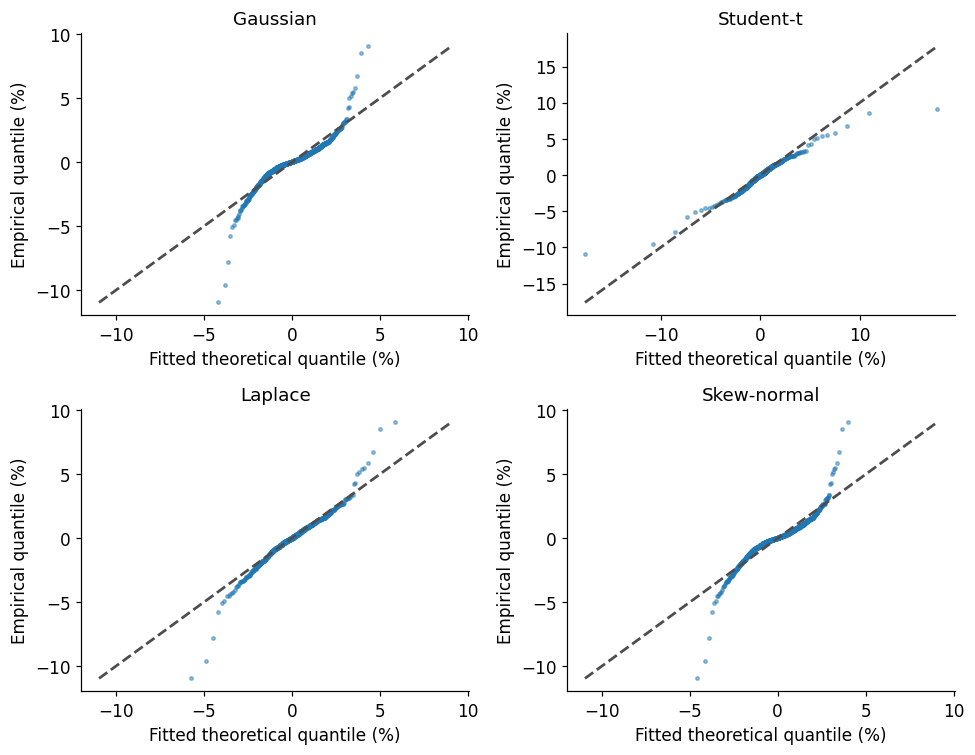

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (name, distribution) in zip(axes.flat, distributions.items()):
    theoretical, observed = qq_data(equity_train, distribution)
    ax.scatter(theoretical, observed, s=5, alpha=.45)
    endpoints = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(endpoints, endpoints, color="0.3", linestyle="--")
    ax.set(title=name, xlabel="Fitted theoretical quantile (%)", ylabel="Empirical quantile (%)")
fig.tight_layout()
plt.show()

### Downside Risk

The likelihood criteria and QQ comparison motivate choosing Student-t as the working parametric model for equity returns. I compare its implied VaR and ES with historical estimates from the training sample, using the loss $L=-R$. The 5% tail level corresponds to the 95th loss quantile.

Both sets of estimates are frozen for the out-of-sample evaluation below. For the fitted return CDF $F_R$, the implied risk measures are

$$\operatorname{VaR}_{\alpha}(L)=-F_R^{-1}(\alpha),\qquad
\operatorname{ES}_{\alpha}(L)=-\frac1\alpha\int_0^\alpha F_R^{-1}(u)\,du.$$

I use the tested Student-t formulas from Notebook 05, with loss location $-\hat\mu$, scale $\hat s$ and degrees of freedom $\hat\nu$. Historical VaR uses the inverse ECDF, while historical ES averages observations **strictly above** that threshold, following the course convention. The table records the number of observations supporting each historical tail average. The table uses the 5% tail level. The figure places the 5% VaR and ES in the loss distribution, with an enlarged tail view. The histogram is an empirical density description, while the smooth PDF comes from the fitted Student-t model. Solid lines mark VaR, a threshold. Dashed lines mark ES, the mean loss beyond that threshold. The shaded fitted tail beyond Student-t VaR has total probability 5%, including the portion beyond the displayed range.

VaR (%)  ES (%)  Strict tail count
alpha Method                                              
0.05  Historical         1.9618  3.1517               75.0
      Fitted Student-t   1.6359  3.2232                NaN

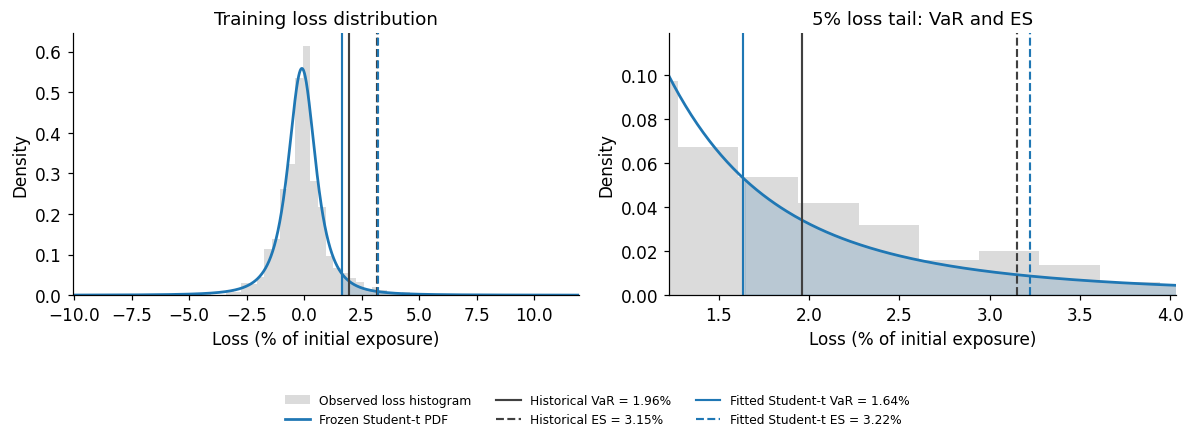

In [6]:
losses = -equity_train
selected_family = equity_family
selected_model = equity_model
parameters = fits[selected_family]["params"]
risk_rows = []
for alpha in [.05]:
    threshold = historical_var(losses, alpha)
    risk_rows.append({"alpha": alpha, "Method": "Historical", "VaR (%)": threshold,
                      "ES (%)": historical_es(losses, alpha),
                      "Strict tail count": int((losses > threshold).sum())})
    if selected_family == "Student-t":
        var = student_t_var(-parameters["mu"], parameters["scale"], parameters["df"], alpha)
        es = student_t_es(-parameters["mu"], parameters["scale"], parameters["df"], alpha)
    elif selected_family == "Gaussian":
        var = gaussian_var(-parameters["mu"], parameters["sigma"], alpha)
        es = gaussian_es(-parameters["mu"], parameters["sigma"], alpha)
    else:
        var = -selected_model.ppf(alpha)
        es = quad(lambda loss: loss*selected_model.pdf(-loss), var, np.inf)[0]/alpha
    np.testing.assert_allclose(var, -selected_model.ppf(alpha))
    risk_rows.append({"alpha": alpha, "Method": f"Fitted {selected_family}",
                      "VaR (%)": var, "ES (%)": es, "Strict tail count": np.nan})
risk_table = pd.DataFrame(risk_rows)
equity_training_risk = risk_table.copy(deep=True)
display(risk_table.set_index(["alpha", "Method"]).round(4))
# Show the 5% comparison in the full loss distribution and a tail enlargement.
alpha = .05
comparison = risk_table[risk_table.alpha == alpha].set_index("Method")
loss_density = lambda values: selected_model.pdf(-values)
loss_grid = np.linspace(losses.min()-1, losses.max()+1, 2001)
fitted_density = loss_density(loss_grid)
fitted_var = comparison.loc[f"Fitted {selected_family}", "VaR (%)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax in axes:
    ax.hist(losses, bins=60, density=True, color="0.6", alpha=.35, label="Observed loss histogram")
    ax.plot(loss_grid, fitted_density, color="C0", label=f"Frozen {selected_family} PDF")
    ax.fill_between(loss_grid, 0, fitted_density, where=loss_grid >= fitted_var,
                    color="C0", alpha=.18)
    for method, color in [("Historical", "0.25"), (f"Fitted {selected_family}", "C0")]:
        for measure, style in [("VaR (%)", "-"), ("ES (%)", "--")]:
            value = comparison.loc[method, measure]
            ax.axvline(value, color=color, linestyle=style, linewidth=1.4,
                       label=f"{method} {measure.split()[0]} = {value:.2f}%")
    ax.set(xlabel="Loss (% of initial exposure)", ylabel="Density")
axes[0].set(title="Training loss distribution", xlim=(loss_grid.min(), loss_grid.max()))
tail_left = comparison["VaR (%)"].min()*.75
tail_right = comparison["ES (%)"].max()*1.25
heights, edges = np.histogram(losses, bins=60, density=True)
tail_bins = (edges[1:] > tail_left) & (edges[:-1] < tail_right)
tail_pdf = loss_density(np.linspace(tail_left, tail_right, 501))
axes[1].set(title="5% loss tail: VaR and ES", xlim=(tail_left, tail_right),
            ylim=(0, 1.2*max(heights[tail_bins].max(), tail_pdf.max())))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8)
fig.tight_layout(rect=(0, .15, 1, 1))
plt.show()

The historical estimates summarize the observed training tail, while fitted ES also depends on the assumed unobserved tail. That extrapolation is particularly sensitive when Student-t degrees of freedom are close to two. The in-sample comparison identifies a working model; the next step asks whether its fixed expectations agree with subsequent observations.

### Out-of-Sample Evaluation

The estimates describe what I would have expected at the end of 2022. I now compare those fixed expectations with the returns observed in 2023–2025. First I examine average return, dispersion and distributional shape, then I assess how frequently large losses occurred and how severe they were. The training empirical baseline and fitted model are both kept fixed throughout this comparison.

#### Return, Dispersion and Distribution

I compare two predictions constructed **only from training data**: the frozen Student-t model and the training empirical baseline. The out-of-sample empirical distribution is the observed outcome, not a competing prediction. Neither prediction is refitted.

The table compares predicted means and standard deviations with the realized out-of-sample moments. The empirical baseline assigns probability $1/n$ to each training return, so its distributional standard deviation uses denominator $n$. The observed test standard deviation uses $m-1$. The model's degrees of freedom remain the training estimate, not an out-of-sample parameter estimate.

For an investment interpretation, I also report mean divided by standard deviation per observation interval. This is a **return-to-volatility ratio**, not a Sharpe ratio: no risk-free return has been deducted, and the ratio is not annualized. Expected return is an average prediction, not a promise about the return on any particular observation.

The figure compares the out-of-sample histogram/KDE with the frozen density and the training empirical histogram. The QQ panel compares the same test quantiles with both frozen parametric and training empirical reference quantiles.

,Mean (%),SD (%),Return / volatility
Training empirical prediction,0.0499,1.2510,0.0399
Frozen Student-t prediction,0.0975,1.8924,0.0515
Out-of-sample realization,0.0868,0.9665,0.0898


Frozen Student-t degrees of freedom: 2.2593


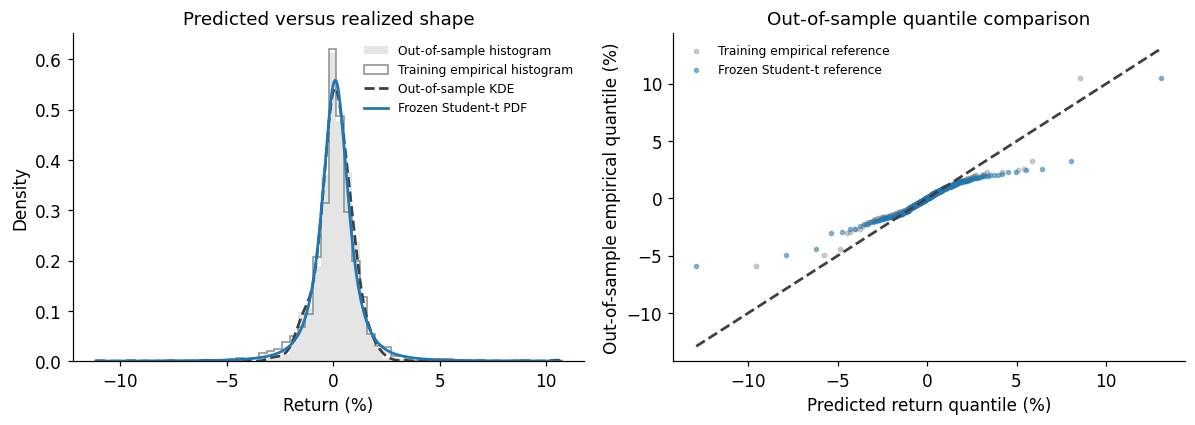

In [7]:
empirical_prediction_mean = sample_mean(equity_train)
empirical_prediction_sd = sample_standard_deviation(equity_train, ddof=0)
model_mean, model_sd = equity_model.mean(), equity_model.std()
observed_mean, observed_sd = sample_mean(equity_test), sample_standard_deviation(equity_test)
means = np.array([empirical_prediction_mean, model_mean, observed_mean])
standard_deviations = np.array([empirical_prediction_sd, model_sd, observed_sd])
display(pd.DataFrame({"Mean (%)": means, "SD (%)": standard_deviations,
                      "Return / volatility": means/standard_deviations},
                     index=["Training empirical prediction", f"Frozen {equity_family} prediction",
                            "Out-of-sample realization"]).round(4))
print("Frozen Student-t degrees of freedom:", round(fits["Student-t"]["params"]["df"], 4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
minimum = min(equity_train.min(), equity_test.min())-.2
maximum = max(equity_train.max(), equity_test.max())+.2
edges = np.linspace(minimum, maximum, 61)
grid = np.linspace(minimum, maximum, 1201)
axes[0].hist(equity_test, bins=edges, density=True, color="0.6", alpha=.25, label="Out-of-sample histogram")
axes[0].hist(equity_train, bins=edges, density=True, histtype="step", color="0.55", linewidth=1,
             label="Training empirical histogram")
axes[0].plot(grid, stats.gaussian_kde(equity_test)(grid), color="0.25", linestyle="--",
             label="Out-of-sample KDE")
axes[0].plot(grid, equity_model.pdf(grid), color="C0", label=f"Frozen {equity_family} PDF")
axes[0].set(title="Predicted versus realized shape", xlabel="Return (%)", ylabel="Density")
axes[0].legend(fontsize=8)
theoretical, observed = qq_data(equity_test, equity_model)
probabilities = (np.arange(1, len(equity_test)+1)-.5)/len(equity_test)
training_quantiles = np.array([empirical_quantile(equity_train, q) for q in probabilities])
axes[1].scatter(training_quantiles, observed, s=8, alpha=.4, color="0.55", label="Training empirical reference")
axes[1].scatter(theoretical, observed, s=7, alpha=.5, color="C0", label=f"Frozen {equity_family} reference")
endpoints = [min(theoretical.min(), training_quantiles.min(), observed.min()),
             max(theoretical.max(), training_quantiles.max(), observed.max())]
axes[1].plot(endpoints, endpoints, "--", color="0.25")
axes[1].set(title="Out-of-sample quantile comparison", xlabel="Predicted return quantile (%)",
            ylabel="Out-of-sample empirical quantile (%)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The Student-t mean is closer to the realized average than the training empirical mean: 0.0975% versus 0.0868% realized, compared with the empirical prediction of 0.0499%. However, the empirical baseline predicts dispersion more closely. It implies SD about 1.25%, while Student-t implies 1.89%, compared with 0.97% realized.

The fitted model is therefore not better on every aspect of the investment outlook. A close mean prediction can coexist with substantially overestimated dispersion, and the QQ plots show remaining differences in the tails.

#### Downside Risk

The purpose is to assess whether the loss estimates would have provided useful expectations about downside exposure. **VaR concerns the frequency of crossing a loss threshold. ES concerns the average severity of losses beyond that threshold.** Neither is a maximum possible loss.

I now evaluate the historical and fitted VaR/ES estimates frozen at the end of training. For each frozen loss threshold $q_\alpha$, the realized exceedance rate and average loss above that threshold are

$$\hat p_{\mathrm{test}}=\frac1m\sum_{i=1}^m I(l_i^{\mathrm{test}}>q_\alpha),\qquad
\bar l_{\mathrm{test},>q}=\frac{\sum_i l_i^{\mathrm{test}}I(l_i^{\mathrm{test}}>q_\alpha)}{\sum_i I(l_i^{\mathrm{test}}>q_\alpha)}.$$

I use $\alpha=5\%$ throughout. A calibrated VaR would be exceeded about 5% of the time, allowing for sample variation. The tables compare predicted ES with both the mean loss above each predicted VaR and the common out-of-sample empirical ES, calculated above the test sample's own 95th loss quantile.

The two panels compare the right-hand loss tails with the same out-of-sample histogram. The empirical panel overlays an in-sample histogram, while the parametric panel overlays the frozen Student-t PDF. Both panels use identical bins and axes. Histogram densities are normalized over the full samples, so zooming into the tail does not change their probability scale. Historical risk estimates remain ECDF-based.

Each panel shows the predicted 5% VaR and ES, the observed percentage exceeding that VaR, and the **ex-post tail mean** above that same threshold. This realized mean is the natural severity check for the forecast threshold, but need not estimate population 5% ES if the threshold is miscalibrated. The common test empirical ES in the tables uses its own test threshold. Exceedance percentages and tail means are calculated from the observations, not from the histogram. All densities retain full-sample normalization.


**Training Empirical Distribution Performance** — 752 out-of-sample observations.

VaR — frequency                                         \
           Frozen threshold (%) Observed exceedances Observed rate (%)   
Tail level                                                               
5%                        1.962             13 / 752             1.729   

                                    ES — severity  \
           Nominal rate (%) Frozen prediction (%)   
Tail level                                          
5%                      5.0                 3.152   

                                                               
           Mean above predicted VaR (%) Test empirical ES (%)  
Tail level                                                     
5%                                3.029                 2.129

**Frozen Student-t Performance** — 752 out-of-sample observations.

VaR — frequency                                         \
           Frozen threshold (%) Observed exceedances Observed rate (%)   
Tail level                                                               
5%                        1.636             25 / 752             3.324   

                                    ES — severity  \
           Nominal rate (%) Frozen prediction (%)   
Tail level                                          
5%                      5.0                 3.223   

                                                               
           Mean above predicted VaR (%) Test empirical ES (%)  
Tail level                                                     
5%                                2.412                 2.129

**5% common evaluation reference:** test empirical VaR **1.416%**, empirical ES **2.129%**, based on **37 strictly exceeding losses**. Nominal expected exceedances: **37.60**.

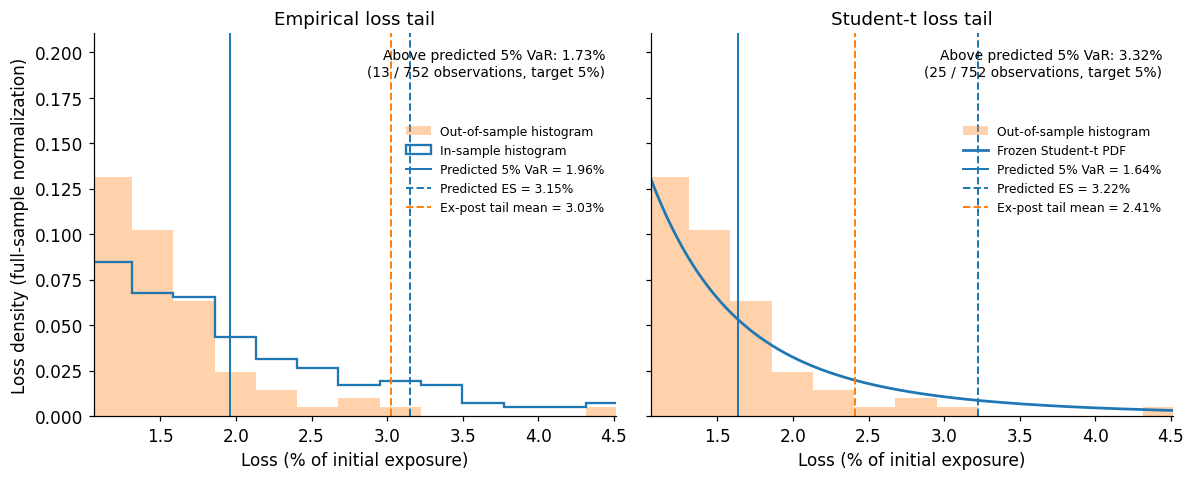

In [8]:
test_losses = -equity_test
# Evaluation references use the test sample only; frozen forecasts remain unchanged.
empirical_test_risk = {}
for alpha in [.05]:
    test_var = historical_var(test_losses, alpha)
    empirical_test_risk[alpha] = {"VaR": test_var, "ES": historical_es(test_losses, alpha),
                                "count": int((test_losses > test_var).sum())}
evaluation_rows = []
for _, row in equity_training_risk.iterrows():
    beyond = test_losses > row["VaR (%)"]
    count = int(beyond.sum())
    evaluation_rows.append({"alpha": row["alpha"], "Method": row["Method"],
                           "Frozen VaR (%)": row["VaR (%)"], "Frozen ES (%)": row["ES (%)"],
                           "Observed exceedance (%)": 100*beyond.mean(),
                           "Target exceedance (%)": 100*row["alpha"],
                           "Exceedances": count, "Out-of-sample n": len(test_losses),
                           "Mean loss above frozen VaR (%)": test_losses[beyond].mean() if count else np.nan,
                           "Out-of-sample empirical ES (%)": empirical_test_risk[row["alpha"]]["ES"]})
evaluation_table = pd.DataFrame(evaluation_rows)
equity_evaluation = evaluation_table.copy(deep=True)
for method, title in [("Historical", "Training Empirical Distribution Performance"),
                      (f"Fitted {equity_family}", f"Frozen {equity_family} Performance")]:
    rows = evaluation_table[evaluation_table.Method == method].set_index("alpha")
    display(Markdown(f"**{title}** — {len(test_losses)} out-of-sample observations."))
    clear_table = pd.DataFrame({
        ("VaR — frequency", "Frozen threshold (%)"): rows["Frozen VaR (%)"],
        ("VaR — frequency", "Observed exceedances"): rows["Exceedances"].map(lambda count: f"{int(count)} / {len(test_losses)}"),
        ("VaR — frequency", "Observed rate (%)"): rows["Observed exceedance (%)"],
        ("VaR — frequency", "Nominal rate (%)"): rows["Target exceedance (%)"],
        ("ES — severity", "Frozen prediction (%)"): rows["Frozen ES (%)"],
        ("ES — severity", "Mean above predicted VaR (%)"): rows["Mean loss above frozen VaR (%)"],
        ("ES — severity", "Test empirical ES (%)"): rows["Out-of-sample empirical ES (%)"]})
    clear_table.columns = pd.MultiIndex.from_tuples(clear_table.columns)
    clear_table.index = [f"{100*alpha:g}%" for alpha in clear_table.index]
    clear_table.index.name = "Tail level"
    display(clear_table.round(3))
for alpha in [.05]:
    reference = empirical_test_risk[alpha]
    display(Markdown(f'**{100*alpha:g}% common evaluation reference:** test empirical VaR '
                     f'**{reference["VaR"]:.3f}%**, empirical ES **{reference["ES"]:.3f}%**, '
                     f'based on **{reference["count"]} strictly exceeding losses**. '
                     f'Nominal expected exceedances: **{alpha*len(test_losses):.2f}**.'))

# Shared bins cover the complete samples; zooming does not renormalize tail probability.
training_losses = -equity_train
alpha = .05
comparison = evaluation_table[evaluation_table.alpha == alpha].set_index("Method")
edges = np.linspace(min(training_losses.min(), test_losses.min())-.2,
                    max(training_losses.max(), test_losses.max())+.2, 81)
tail_left = min(comparison["Frozen VaR (%)"].min(), empirical_test_risk[alpha]["VaR"])*.75
tail_right = max(comparison["Frozen ES (%)"].max(),
                 comparison["Mean loss above frozen VaR (%)"].max(), empirical_test_risk[alpha]["ES"])*1.4
grid = np.linspace(tail_left, tail_right, 1601)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, method in zip(axes, ["Historical", f"Fitted {equity_family}"]):
    ax.hist(test_losses, bins=edges, density=True, color="C1", alpha=.35,
            label="Out-of-sample histogram")
    if method == "Historical":
        ax.hist(training_losses, bins=edges, density=True, histtype="step",
                color="C0", linewidth=1.5, label="In-sample histogram")
    else:
        ax.plot(grid, equity_model.pdf(-grid), color="C0", label="Frozen Student-t PDF")
    values = comparison.loc[method]
    ax.axvline(values["Frozen VaR (%)"], color="C0", linewidth=1.3,
               label=f'Predicted 5% VaR = {values["Frozen VaR (%)"]:.2f}%')
    ax.axvline(values["Frozen ES (%)"], color="C0", linestyle="--", linewidth=1.3,
               label=f'Predicted ES = {values["Frozen ES (%)"]:.2f}%')
    ax.axvline(values["Mean loss above frozen VaR (%)"], color="C1", linestyle="--", linewidth=1.3,
               label=f'Ex-post tail mean = {values["Mean loss above frozen VaR (%)"]:.2f}%')
    ax.set_title("Empirical loss tail" if method == "Historical" else "Student-t loss tail")
    ax.text(.98, .96,
            f'Above predicted 5% VaR: {values["Observed exceedance (%)"]:.2f}%\n'
            f'({int(values["Exceedances"])} / {len(test_losses)} observations, target 5%)',
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set(xlabel="Loss (% of initial exposure)", xlim=(tail_left, tail_right))
    ax.legend(loc="upper right", bbox_to_anchor=(1, .79), fontsize=8)
train_heights, _ = np.histogram(training_losses, bins=edges, density=True)
test_heights, _ = np.histogram(test_losses, bins=edges, density=True)
visible = (edges[1:] > tail_left) & (edges[:-1] < tail_right)
upper = max(train_heights[visible].max(), test_heights[visible].max(), equity_model.pdf(-grid).max())*1.6
axes[0].set(ylim=(0, upper), ylabel="Loss density (full-sample normalization)")
fig.tight_layout()
plt.show()


The equity Student-t 5% VaR is exceeded in 25 of 752 observations (3.32%), compared with 13 (1.73%) for the empirical baseline. Both thresholds are conservative in this period, with Student-t closer to the nominal 5% frequency.

Losses above the Student-t threshold average 2.41%, compared with predicted ES of 3.22%. Above the empirical threshold they average 3.03%, compared with predicted ES of 3.15%. The common test empirical ES is 2.13%. Thus Student-t performs better on exceedance frequency here, while the empirical ES prediction is closer to the common realized reference. Frequency and severity need not favor the same method.

The equity example therefore separates choosing a distribution from evaluating its predictions. I next apply the same procedure to bonds to see whether the conclusions carry over to a different asset.

## 3. Univariate Example: Bond Returns

I apply the same sequence to AGG: empirical description, parametric estimation, loss risk and out-of-sample evaluation. The periods, return convention and units are identical to those for equities. Each asset has its own fitted parameters, and all calculations before **Out-of-Sample Evaluation** use 2017–2022.

Bond-fund returns reflect changes in the value of the underlying bonds together with distribution adjustments. They are investment-return proxies rather than changes in a quoted bond yield.

### Empirical Distribution and Moments

The moments, histogram/KDE and ECDF summarize the observed bond returns. Dispersion is much smaller than for equities, but negative skewness and high raw kurtosis remain. Smaller dispersion does not imply the absence of extreme observations relative to the asset's own scale.

,n,Mean (%),Variance (%²),SD (%),Skewness,Raw kurtosis
AGG,1509,0.0028,0.1141,0.3378,-1.7891,34.0118


Observations outside the density display [-1.5%, 1.5%]: 10


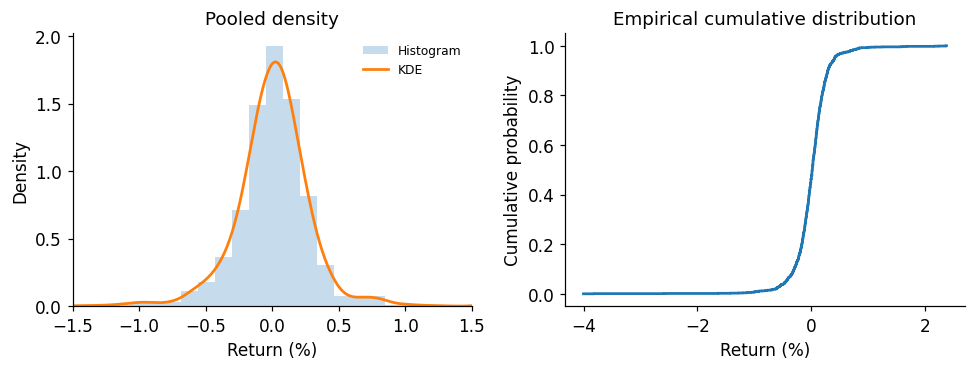

In [9]:
display(pd.DataFrame({"n": [len(bond_train)], "Mean (%)": [sample_mean(bond_train)],
    "Variance (%²)": [sample_variance(bond_train)], "SD (%)": [sample_standard_deviation(bond_train)],
    "Skewness": [sample_skewness(bond_train)], "Raw kurtosis": [sample_kurtosis(bond_train)]}, index=["AGG"]).round(4))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
grid = np.linspace(bond_train.min()-.1, bond_train.max()+.1, 1001)
axes[0].hist(bond_train, bins=50, density=True, alpha=.25, label="Histogram")
axes[0].plot(grid, stats.gaussian_kde(bond_train)(grid), label="KDE")
axes[0].set(title="Pooled density", xlabel="Return (%)", ylabel="Density", xlim=(-1.5,1.5))
print("Observations outside the density display [-1.5%, 1.5%]:", int((abs(bond_train)>1.5).sum()))
axes[0].legend(fontsize=8)
axes[1].step(np.sort(bond_train), empirical_cdf(bond_train)(np.sort(bond_train)), where="post")
axes[1].set(title="Empirical cumulative distribution", xlabel="Return (%)", ylabel="Cumulative probability")
fig.tight_layout()
plt.show()

### Parametric Models and Estimation

I compare the same four families using only bond training observations. Each marginal has its own parameters. The equity fit is not transferred to bonds.

Student-t and Laplace again have the lowest training AIC and BIC, with Student-t ahead by about 90 AIC points and 85 BIC points. Training BIC therefore selects Student-t for bonds as well. Its fitted degrees of freedom are about 2.72, allowing finite variance but no finite fourth moment. These estimates are frozen for evaluation.

In [10]:
bond_fits = market_fits["Bonds (AGG)"]
bond_distributions = fitted_distributions["Bonds (AGG)"]
display(fit_table.loc["Bonds (AGG)"].round(4))
print("Selected bond family (training BIC):", preferred_family["Bonds (AGG)"])
bond_family = preferred_family["Bonds (AGG)"]
bond_model = bond_distributions[bond_family]

,location,scale,df,shape,implied mean,implied SD,log-likelihood,k,AIC,BIC
family,,,,,,,,,,
Gaussian,0.0028,0.3377,NaN,NaN,0.0028,0.3377,-503.1664,2,1010.3328,1020.9712
Student-t,0.0125,0.1780,2.7231,NaN,0.0125,0.3454,-128.2879,3,262.5758,278.5334
Laplace,0.0169,0.2065,NaN,NaN,0.0169,0.2920,-174.3208,2,352.6416,363.2800
Skew-normal,0.2485,0.4177,NaN,-1.1612,-0.0040,0.3327,-471.2091,3,948.4181,964.3757


Selected bond family (training BIC): Student-t


### Quantile Comparisons

I compare bond training quantiles with the quantiles of each fitted family. Student-t captures more of the tail range than Gaussian or Laplace, but the largest negative movements remain difficult to describe with a symmetric model. These plots diagnose the training fit rather than justify changing the selected model after seeing the out-of-sample observations.

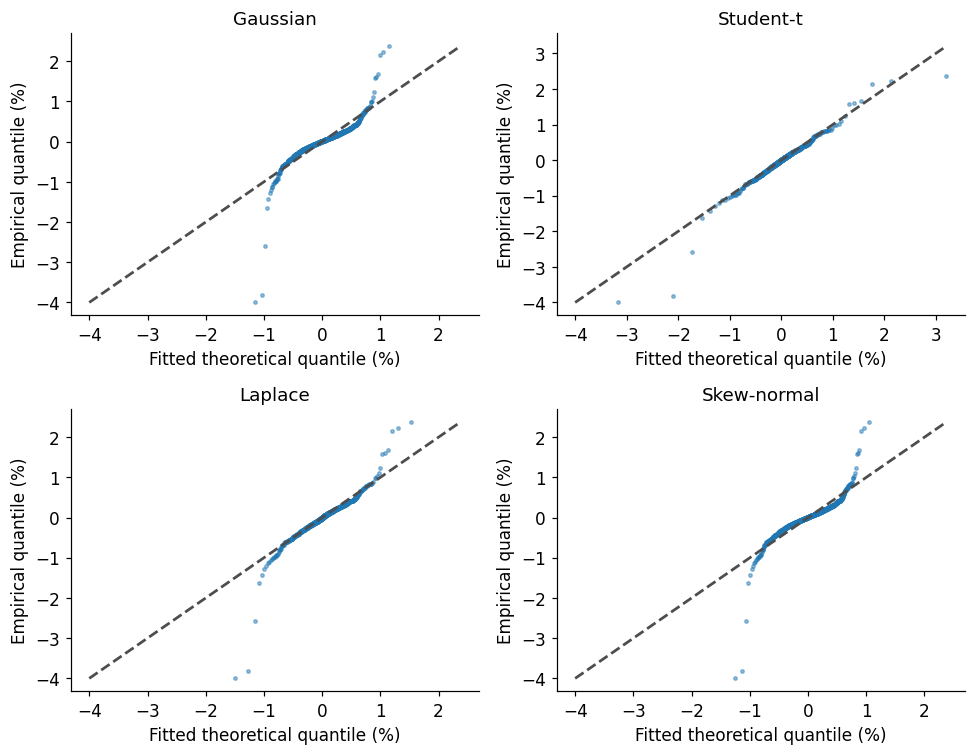

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
for ax, (name, distribution) in zip(axes.flat, bond_distributions.items()):
    theoretical, observed = qq_data(bond_train, distribution)
    ax.scatter(theoretical, observed, s=5, alpha=.45)
    endpoints = [min(theoretical.min(), observed.min()), max(theoretical.max(), observed.max())]
    ax.plot(endpoints, endpoints, color="0.3", linestyle="--")
    ax.set(title=name, xlabel="Fitted theoretical quantile (%)", ylabel="Empirical quantile (%)")
fig.tight_layout()
plt.show()

### Downside Risk

Student-t is also the working parametric choice for bonds, based on its likelihood criteria and the quantile comparison. I use the same loss convention and 5% tail level as for equities, with the bond-specific fitted parameters.

The table compares historical and fitted VaR/ES using bond training observations. Both sets of estimates are frozen for evaluation. The figure shows the loss histogram and Student-t PDF, then enlarges the 5% tail. Solid lines mark VaR thresholds and dashed lines mark ES tail means. The shaded Student-t tail has total probability 5%, including its continuation beyond the display.

VaR (%)  ES (%)  Strict tail count
alpha Method                                              
0.05  Historical         0.4465  0.7981               75.0
      Fitted Student-t   0.4242  0.7380                NaN

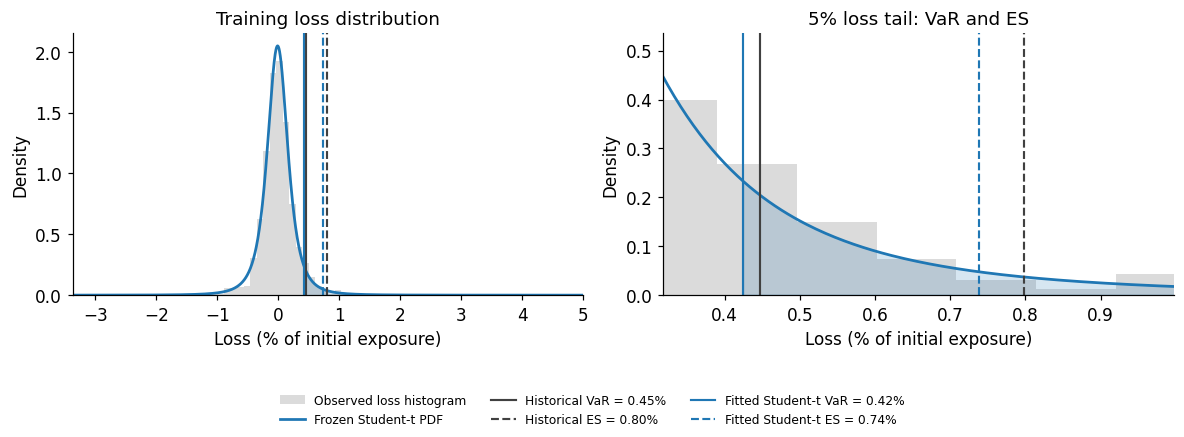

In [12]:
losses = -bond_train
selected_family = bond_family
selected_model = bond_model
parameters = bond_fits[selected_family]["params"]
risk_rows = []
for alpha in [.05]:
    threshold = historical_var(losses, alpha)
    risk_rows.append({"alpha": alpha, "Method": "Historical", "VaR (%)": threshold,
                      "ES (%)": historical_es(losses, alpha),
                      "Strict tail count": int((losses > threshold).sum())})
    if selected_family == "Student-t":
        var = student_t_var(-parameters["mu"], parameters["scale"], parameters["df"], alpha)
        es = student_t_es(-parameters["mu"], parameters["scale"], parameters["df"], alpha)
    elif selected_family == "Gaussian":
        var = gaussian_var(-parameters["mu"], parameters["sigma"], alpha)
        es = gaussian_es(-parameters["mu"], parameters["sigma"], alpha)
    else:
        var = -selected_model.ppf(alpha)
        es = quad(lambda loss: loss*selected_model.pdf(-loss), var, np.inf)[0]/alpha
    np.testing.assert_allclose(var, -selected_model.ppf(alpha))
    risk_rows.append({"alpha": alpha, "Method": f"Fitted {selected_family}",
                      "VaR (%)": var, "ES (%)": es, "Strict tail count": np.nan})
risk_table = pd.DataFrame(risk_rows)
bond_training_risk = risk_table.copy(deep=True)
display(risk_table.set_index(["alpha", "Method"]).round(4))
# Show the 5% comparison in the full loss distribution and a tail enlargement.
alpha = .05
comparison = risk_table[risk_table.alpha == alpha].set_index("Method")
loss_density = lambda values: selected_model.pdf(-values)
loss_grid = np.linspace(losses.min()-1, losses.max()+1, 2001)
fitted_density = loss_density(loss_grid)
fitted_var = comparison.loc[f"Fitted {selected_family}", "VaR (%)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax in axes:
    ax.hist(losses, bins=60, density=True, color="0.6", alpha=.35, label="Observed loss histogram")
    ax.plot(loss_grid, fitted_density, color="C0", label=f"Frozen {selected_family} PDF")
    ax.fill_between(loss_grid, 0, fitted_density, where=loss_grid >= fitted_var,
                    color="C0", alpha=.18)
    for method, color in [("Historical", "0.25"), (f"Fitted {selected_family}", "C0")]:
        for measure, style in [("VaR (%)", "-"), ("ES (%)", "--")]:
            value = comparison.loc[method, measure]
            ax.axvline(value, color=color, linestyle=style, linewidth=1.4,
                       label=f"{method} {measure.split()[0]} = {value:.2f}%")
    ax.set(xlabel="Loss (% of initial exposure)", ylabel="Density")
axes[0].set(title="Training loss distribution", xlim=(loss_grid.min(), loss_grid.max()))
tail_left = comparison["VaR (%)"].min()*.75
tail_right = comparison["ES (%)"].max()*1.25
heights, edges = np.histogram(losses, bins=60, density=True)
tail_bins = (edges[1:] > tail_left) & (edges[:-1] < tail_right)
tail_pdf = loss_density(np.linspace(tail_left, tail_right, 501))
axes[1].set(title="5% loss tail: VaR and ES", xlim=(tail_left, tail_right),
            ylim=(0, 1.2*max(heights[tail_bins].max(), tail_pdf.max())))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8)
fig.tight_layout(rect=(0, .15, 1, 1))
plt.show()

The bond fit again favors Student-t in sample. I now keep its parameters and the empirical baseline fixed, asking whether their implied return distribution and loss thresholds describe the subsequent period. The out-of-sample observations are used for evaluation, not re-estimation.

### Out-of-Sample Evaluation

I now compare the bond predictions fixed at the end of 2022 with the returns observed in 2023–2025. I use the same empirical baseline, evaluation measures and figure layouts as in the equity case, with bond-specific fitted parameters. Neither prediction is refitted.

#### Return, Dispersion and Distribution

The table compares expected and realized mean, standard deviation and return-to-volatility ratio. The empirical baseline uses the training observations with equal weights; its standard deviation uses the full empirical distribution, while the realized sample estimate uses the degrees-of-freedom correction. The ratio is not a Sharpe ratio.

The density and QQ panels compare the observed test distribution with the frozen fitted model and training empirical reference. These comparisons concern average return, dispersion and shape before I examine downside risk.


,Mean (%),SD (%),Return / volatility
Training empirical prediction,0.0028,0.3377,0.0082
Frozen Student-t prediction,0.0125,0.3454,0.0363
Out-of-sample realization,0.0190,0.3751,0.0506


Frozen Student-t degrees of freedom: 2.7231


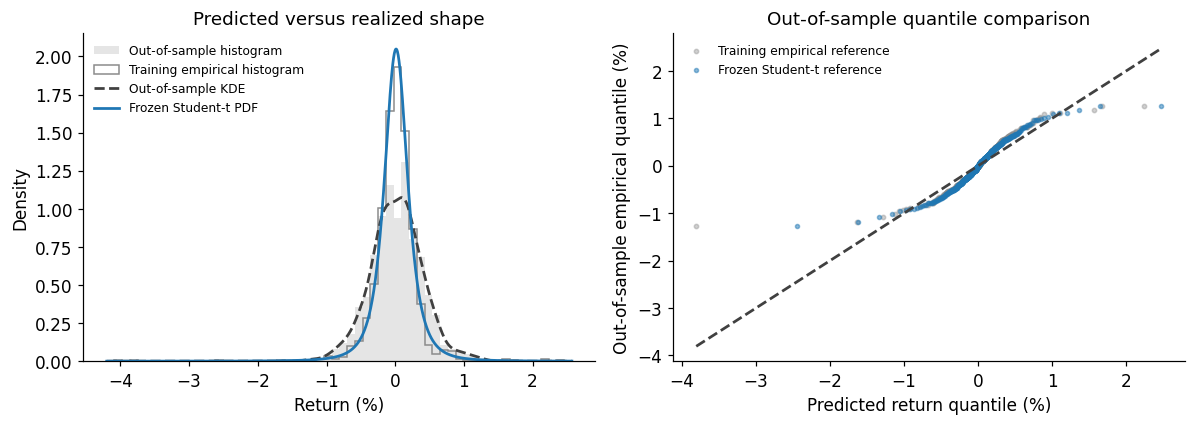

In [13]:
empirical_prediction_mean = sample_mean(bond_train)
empirical_prediction_sd = sample_standard_deviation(bond_train, ddof=0)
model_mean, model_sd = bond_model.mean(), bond_model.std()
observed_mean, observed_sd = sample_mean(bond_test), sample_standard_deviation(bond_test)
means = np.array([empirical_prediction_mean, model_mean, observed_mean])
standard_deviations = np.array([empirical_prediction_sd, model_sd, observed_sd])
display(pd.DataFrame({"Mean (%)": means, "SD (%)": standard_deviations,
                      "Return / volatility": means/standard_deviations},
                     index=["Training empirical prediction", f"Frozen {bond_family} prediction",
                            "Out-of-sample realization"]).round(4))
print("Frozen Student-t degrees of freedom:", round(bond_fits["Student-t"]["params"]["df"], 4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
minimum = min(bond_train.min(), bond_test.min())-.2
maximum = max(bond_train.max(), bond_test.max())+.2
edges = np.linspace(minimum, maximum, 61)
grid = np.linspace(minimum, maximum, 1201)
axes[0].hist(bond_test, bins=edges, density=True, color="0.6", alpha=.25, label="Out-of-sample histogram")
axes[0].hist(bond_train, bins=edges, density=True, histtype="step", color="0.55", linewidth=1,
             label="Training empirical histogram")
axes[0].plot(grid, stats.gaussian_kde(bond_test)(grid), color="0.25", linestyle="--",
             label="Out-of-sample KDE")
axes[0].plot(grid, bond_model.pdf(grid), color="C0", label=f"Frozen {bond_family} PDF")
axes[0].set(title="Predicted versus realized shape", xlabel="Return (%)", ylabel="Density")
axes[0].legend(fontsize=8)
theoretical, observed = qq_data(bond_test, bond_model)
probabilities = (np.arange(1, len(bond_test)+1)-.5)/len(bond_test)
training_quantiles = np.array([empirical_quantile(bond_train, q) for q in probabilities])
axes[1].scatter(training_quantiles, observed, s=8, alpha=.4, color="0.55", label="Training empirical reference")
axes[1].scatter(theoretical, observed, s=7, alpha=.5, color="C0", label=f"Frozen {bond_family} reference")
endpoints = [min(theoretical.min(), training_quantiles.min(), observed.min()),
             max(theoretical.max(), training_quantiles.max(), observed.max())]
axes[1].plot(endpoints, endpoints, "--", color="0.25")
axes[1].set(title="Out-of-sample quantile comparison", xlabel="Predicted return quantile (%)",
            ylabel="Out-of-sample empirical quantile (%)")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

The Student-t mean and SD are closer to the realized moments than the training empirical baseline. Its mean is about 0.0125%, compared with 0.0190% realized and an empirical prediction of 0.0028%. Its SD is about 0.35%, compared with 0.38% realized.

The QQ plot nevertheless shows differences between the frozen predictions and the test distribution. Closer mean and dispersion do not establish accurate tail risk, which I examine next.

#### Downside Risk

I use the same 5% VaR and ES evaluation as for equities. The two method-based tables compare the training empirical baseline and frozen fitted model with observed exceedance counts and rates, the ex-post mean above each predicted VaR, and the common test empirical ES.

The tail panels retain the same bins and axes for both predictions. The empirical baseline is shown as an in-sample histogram, while the fitted prediction is a PDF. Both are compared with the same out-of-sample histogram, using full-sample density normalization.

The ex-post mean above predicted VaR and test empirical ES use different thresholds. A close tail mean therefore does not by itself establish correct 5% risk calibration.


**Training Empirical Distribution Performance** — 752 out-of-sample observations.

VaR — frequency                                         \
           Frozen threshold (%) Observed exceedances Observed rate (%)   
Tail level                                                               
5%                        0.446             77 / 752            10.239   

                                    ES — severity  \
           Nominal rate (%) Frozen prediction (%)   
Tail level                                          
5%                      5.0                 0.798   

                                                               
           Mean above predicted VaR (%) Test empirical ES (%)  
Tail level                                                     
5%                                0.648                 0.793

**Frozen Student-t Performance** — 752 out-of-sample observations.

VaR — frequency                                         \
           Frozen threshold (%) Observed exceedances Observed rate (%)   
Tail level                                                               
5%                        0.424             79 / 752            10.505   

                                    ES — severity  \
           Nominal rate (%) Frozen prediction (%)   
Tail level                                          
5%                      5.0                 0.738   

                                                               
           Mean above predicted VaR (%) Test empirical ES (%)  
Tail level                                                     
5%                                0.643                 0.793

**5% common evaluation reference:** test empirical VaR **0.598%**, empirical ES **0.793%**, based on **37 strictly exceeding losses**. Nominal expected exceedances: **37.60**.

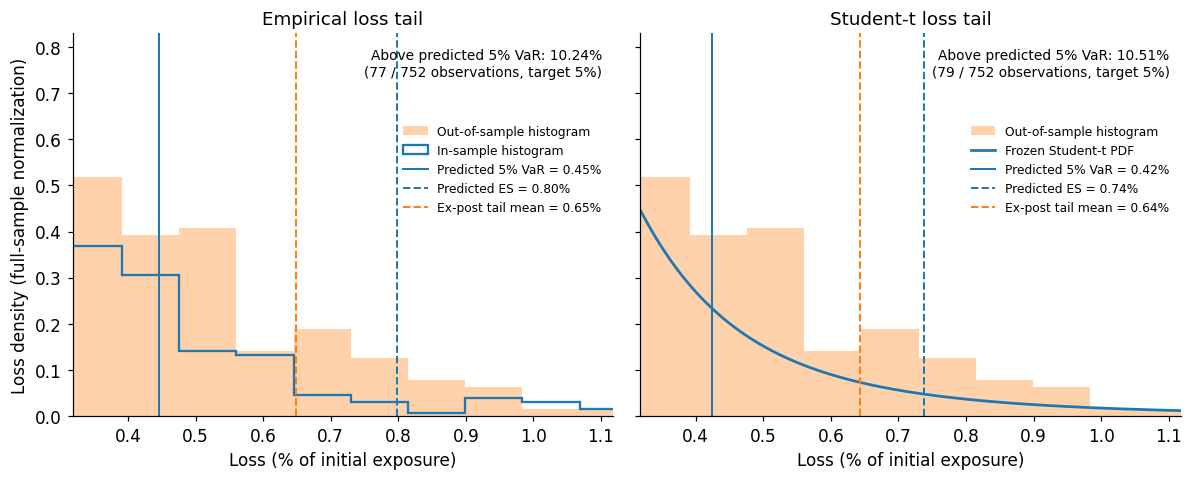

In [14]:
test_losses = -bond_test
# Evaluation references use the test sample only; frozen forecasts remain unchanged.
empirical_test_risk = {}
for alpha in [.05]:
    test_var = historical_var(test_losses, alpha)
    empirical_test_risk[alpha] = {"VaR": test_var, "ES": historical_es(test_losses, alpha),
                                "count": int((test_losses > test_var).sum())}
evaluation_rows = []
for _, row in bond_training_risk.iterrows():
    beyond = test_losses > row["VaR (%)"]
    count = int(beyond.sum())
    evaluation_rows.append({"alpha": row["alpha"], "Method": row["Method"],
                           "Frozen VaR (%)": row["VaR (%)"], "Frozen ES (%)": row["ES (%)"],
                           "Observed exceedance (%)": 100*beyond.mean(),
                           "Target exceedance (%)": 100*row["alpha"],
                           "Exceedances": count, "Out-of-sample n": len(test_losses),
                           "Mean loss above frozen VaR (%)": test_losses[beyond].mean() if count else np.nan,
                           "Out-of-sample empirical ES (%)": empirical_test_risk[row["alpha"]]["ES"]})
evaluation_table = pd.DataFrame(evaluation_rows)
bond_evaluation = evaluation_table.copy(deep=True)
for method, title in [("Historical", "Training Empirical Distribution Performance"),
                      (f"Fitted {bond_family}", f"Frozen {bond_family} Performance")]:
    rows = evaluation_table[evaluation_table.Method == method].set_index("alpha")
    display(Markdown(f"**{title}** — {len(test_losses)} out-of-sample observations."))
    clear_table = pd.DataFrame({
        ("VaR — frequency", "Frozen threshold (%)"): rows["Frozen VaR (%)"],
        ("VaR — frequency", "Observed exceedances"): rows["Exceedances"].map(lambda count: f"{int(count)} / {len(test_losses)}"),
        ("VaR — frequency", "Observed rate (%)"): rows["Observed exceedance (%)"],
        ("VaR — frequency", "Nominal rate (%)"): rows["Target exceedance (%)"],
        ("ES — severity", "Frozen prediction (%)"): rows["Frozen ES (%)"],
        ("ES — severity", "Mean above predicted VaR (%)"): rows["Mean loss above frozen VaR (%)"],
        ("ES — severity", "Test empirical ES (%)"): rows["Out-of-sample empirical ES (%)"]})
    clear_table.columns = pd.MultiIndex.from_tuples(clear_table.columns)
    clear_table.index = [f"{100*alpha:g}%" for alpha in clear_table.index]
    clear_table.index.name = "Tail level"
    display(clear_table.round(3))
for alpha in [.05]:
    reference = empirical_test_risk[alpha]
    display(Markdown(f'**{100*alpha:g}% common evaluation reference:** test empirical VaR '
                     f'**{reference["VaR"]:.3f}%**, empirical ES **{reference["ES"]:.3f}%**, '
                     f'based on **{reference["count"]} strictly exceeding losses**. '
                     f'Nominal expected exceedances: **{alpha*len(test_losses):.2f}**.'))

# Shared bins cover the complete samples; zooming does not renormalize tail probability.
training_losses = -bond_train
alpha = .05
comparison = evaluation_table[evaluation_table.alpha == alpha].set_index("Method")
edges = np.linspace(min(training_losses.min(), test_losses.min())-.2,
                    max(training_losses.max(), test_losses.max())+.2, 81)
tail_left = min(comparison["Frozen VaR (%)"].min(), empirical_test_risk[alpha]["VaR"])*.75
tail_right = max(comparison["Frozen ES (%)"].max(),
                 comparison["Mean loss above frozen VaR (%)"].max(), empirical_test_risk[alpha]["ES"])*1.4
grid = np.linspace(tail_left, tail_right, 1601)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharex=True, sharey=True)
for ax, method in zip(axes, ["Historical", f"Fitted {bond_family}"]):
    ax.hist(test_losses, bins=edges, density=True, color="C1", alpha=.35,
            label="Out-of-sample histogram")
    if method == "Historical":
        ax.hist(training_losses, bins=edges, density=True, histtype="step",
                color="C0", linewidth=1.5, label="In-sample histogram")
    else:
        ax.plot(grid, bond_model.pdf(-grid), color="C0", label="Frozen Student-t PDF")
    values = comparison.loc[method]
    ax.axvline(values["Frozen VaR (%)"], color="C0", linewidth=1.3,
               label=f'Predicted 5% VaR = {values["Frozen VaR (%)"]:.2f}%')
    ax.axvline(values["Frozen ES (%)"], color="C0", linestyle="--", linewidth=1.3,
               label=f'Predicted ES = {values["Frozen ES (%)"]:.2f}%')
    ax.axvline(values["Mean loss above frozen VaR (%)"], color="C1", linestyle="--", linewidth=1.3,
               label=f'Ex-post tail mean = {values["Mean loss above frozen VaR (%)"]:.2f}%')
    ax.set_title("Empirical loss tail" if method == "Historical" else "Student-t loss tail")
    ax.text(.98, .96,
            f'Above predicted 5% VaR: {values["Observed exceedance (%)"]:.2f}%\n'
            f'({int(values["Exceedances"])} / {len(test_losses)} observations, target 5%)',
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
    ax.set(xlabel="Loss (% of initial exposure)", xlim=(tail_left, tail_right))
    ax.legend(loc="upper right", bbox_to_anchor=(1, .79), fontsize=8)
train_heights, _ = np.histogram(training_losses, bins=edges, density=True)
test_heights, _ = np.histogram(test_losses, bins=edges, density=True)
visible = (edges[1:] > tail_left) & (edges[:-1] < tail_right)
upper = max(train_heights[visible].max(), test_heights[visible].max(), bond_model.pdf(-grid).max())*1.6
axes[0].set(ylim=(0, upper), ylabel="Loss density (full-sample normalization)")
fig.tight_layout()
plt.show()


The empirical and Student-t bond 5% VaR thresholds are exceeded in 77 and 79 of 752 observations (10.24% and 10.51%). Both understate how frequently this level of loss occurred out of sample.

The mean loss above the empirical threshold is 0.65%, compared with predicted ES of 0.80%. Above the Student-t threshold it is 0.64%, compared with predicted ES of 0.74%. The common test empirical ES is 0.79%. These comparisons condition on different thresholds, so the tail means alone cannot rank the forecasts.

Across the two assets, Student-t is preferred in sample, but its frozen predictions do not succeed on every out-of-sample measure. I next ask how the marginal predictions change when the assets are estimated together under one joint model.

## 4. Bivariate Example: Equity and Bond Returns

The univariate examples described equity and bond returns separately. I now move into joint distribution space, where each observation is a paired return vector

$$\mathbf R=\begin{pmatrix}R_E\\R_B\end{pmatrix}.$$

The marginals describe each asset, while the joint distribution also describes how their returns occur together. Separate marginal fits do not determine this dependence. A joint model also imposes restrictions on its marginals, so fitting the assets together can change their individual predictions. I follow the same sequence as before: empirical description → parametric estimation and selection → frozen out-of-sample evaluation.

I use the same 2017–2022 training observations and 2023–2025 evaluation window. The working sampling model treats the paired vectors as IID draws from a joint population distribution. Actual financial returns may exhibit temporal dependence, which the later time-series notebooks address. Conditional distributions and linear transformations are deferred.

### Empirical Distribution

The empirical joint distribution gives equal weight to each observed equity–bond return pair. I summarize these observations using the mean vector, covariance matrix and correlation. Correlation measures linear dependence, rather than the complete joint distribution. These descriptions use training observations and are frozen before evaluation.

The reported sample covariance uses the usual degrees-of-freedom correction. The empirical probability distribution itself uses equal observation weights, so its covariance differs slightly from that corrected estimate.

The left panel overlays SPY and AGG histograms and KDEs in the same percentage-return units. These marginal shapes describe each asset separately. The right panel shows the paired returns, making the joint relationship visible.


,Mean (%),SD (%)
Equity (SPY),0.0499,1.2515
Bonds (AGG),0.0028,0.3378


,Equity (SPY),Bonds (AGG)
Equity (SPY),1.5661,0.0541
Bonds (AGG),0.0541,0.1141


Empirical correlation: 0.1279


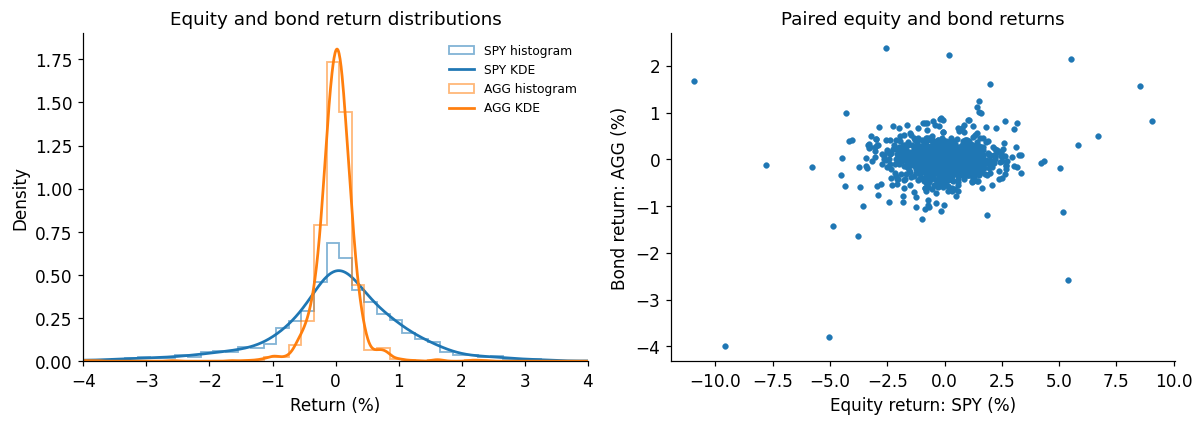

Observations outside marginal display: [22  1]


In [15]:
joint_train = training.to_numpy()
joint_test = test_sample.to_numpy()
joint_labels = list(training.columns)
joint_mean = joint_train.mean(axis=0)
joint_covariance = covariance_matrix(joint_train)
display(pd.DataFrame({"Mean (%)": joint_mean, "SD (%)": np.sqrt(np.diag(joint_covariance))},
                     index=joint_labels).round(4))
display(pd.DataFrame(joint_covariance, index=joint_labels, columns=joint_labels).round(4))
print("Empirical correlation:", round(correlation(*joint_train.T), 4))
# One figure contrasts the marginal shapes with the observed paired relationship.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
marginal_grid = np.linspace(-4, 4, 1001)
edges = np.linspace(joint_train.min(), joint_train.max(), 101)
for j, color in enumerate(["C0", "C1"]):
    values = joint_train[:,j]
    label = "SPY" if j == 0 else "AGG"
    axes[0].hist(values, bins=edges, density=True, histtype="step", color=color,
                 alpha=.55, linewidth=1.2, label=f"{label} histogram")
    axes[0].plot(marginal_grid, stats.gaussian_kde(values)(marginal_grid),
                 color=color, label=f"{label} KDE")
axes[0].set(title="Equity and bond return distributions", xlabel="Return (%)",
            ylabel="Density", xlim=(-4,4))
axes[0].legend(fontsize=8)
axes[1].scatter(*joint_train.T, s=14, alpha=1., facecolors="C0",
                edgecolors="C0", linewidths=.3, rasterized=True)
axes[1].set(xlabel="Equity return: SPY (%)", ylabel="Bond return: AGG (%)",
            title="Paired equity and bond returns")
axes[1].xaxis.label.set_color("black")
axes[1].yaxis.label.set_color("black")
fig.tight_layout()
plt.show()
print("Observations outside marginal display:", (np.abs(joint_train)>4).sum(axis=0))


### Parametric Models and Estimation

I compare Gaussian, Student-t and skew-normal joint models, using the same model-selection approach as in the univariate examples. Their bivariate forms follow Notebook 02. I estimate them from the paired observations, rather than combining separately fitted densities.

#### Choosing a Parametric Model

I use AIC and BIC as in the univariate examples, select the lowest BIC among models with a finite fitted maximum likelihood, and freeze its parameters. The joint Gaussian has five parameters, Student-t six, and the location-and-scale skew-normal seven. The latter extends the standard skew-normal form from Notebook 02 to observed return units. Its location and scale matrix are not generally its mean and covariance. Numerical fits use several starting values; finite shape bounds and any bound hits are reported.

The table compares the fitted models using their joint training-sample likelihoods, AIC and BIC.

In [16]:
gaussian_cov = covariance_matrix(joint_train, ddof=0)
gaussian_joint = stats.multivariate_normal(mean=joint_mean, cov=gaussian_cov)
t_fit = multivariate_t_mle(joint_train)
t_joint = stats.multivariate_t(loc=t_fit["location"], shape=t_fit["scale"], df=t_fit["df"])
skew_fit = multivariate_skew_normal_mle(joint_train)
skew_mean, skew_cov = multivariate_skew_normal_moments(
    skew_fit["location"], skew_fit["scale"], skew_fit["shape"])
skew_density = lambda points: np.exp(multivariate_skew_normal_logpdf(
    points, skew_fit["location"], skew_fit["scale"], skew_fit["shape"]))
joint_densities = {"Gaussian": gaussian_joint.pdf, "Student-t": t_joint.pdf,
                   "Skew-normal": skew_density}
joint_rows = []
for name, ll, k in [("Gaussian", gaussian_joint.logpdf(joint_train).sum(), 5),
                    ("Student-t", t_fit["log_likelihood"], 6),
                    ("Skew-normal", skew_fit["log_likelihood"], 7)]:
    joint_rows.append({"Model": name, "Estimation": "Maximum likelihood", "k": k,
                       "Log-likelihood": ll, "AIC": aic(ll, k), "BIC": bic(ll, k, len(joint_train))})
joint_selection = pd.DataFrame(joint_rows).set_index("Model").reindex(
    ["Gaussian", "Student-t", "Skew-normal"])
display(joint_selection.round(3))
joint_family = joint_selection["BIC"].idxmin()
print("Selected joint family (training BIC):", joint_family)
print("Skew-normal fitted shape:", skew_fit["shape"].round(4),
      "— shape bound hit:", skew_fit["shape_bound_hit"])
if joint_family == "Student-t":
    joint_model = t_joint
    selected_mean, selected_scale = t_fit["location"], t_fit["scale"]
    selected_cov = selected_scale*t_fit["df"]/(t_fit["df"]-2)
    joint_marginals = [stats.t(t_fit["df"], loc=selected_mean[j],
                             scale=np.sqrt(selected_scale[j,j])) for j in range(2)]
    print("Common degrees of freedom:", round(t_fit["df"], 4))
elif joint_family == "Gaussian":
    joint_model = gaussian_joint
    selected_mean, selected_cov = joint_mean, gaussian_cov
    joint_marginals = [stats.norm(selected_mean[j], np.sqrt(selected_cov[j,j])) for j in range(2)]
else:
    selected_mean, selected_cov = skew_mean, skew_cov
    sd = np.sqrt(np.diag(skew_fit["scale"]))
    omega = skew_fit["scale"]/np.outer(sd,sd)
    alpha = skew_fit["shape"]
    delta = omega@alpha/np.sqrt(1+alpha@omega@alpha)
    marginal_shapes = delta/np.sqrt(1-delta**2)
    joint_marginals = [stats.skewnorm(marginal_shapes[j],loc=skew_fit["location"][j],scale=sd[j])
                       for j in range(2)]
selected_rho = selected_cov[0,1]/np.sqrt(selected_cov[0,0]*selected_cov[1,1])
selected_density = joint_densities[joint_family]


,Estimation,k,Log-likelihood,AIC,BIC
Model,,,,,
Gaussian,Maximum likelihood,5,-2969.875,5949.750,5976.346
Student-t,Maximum likelihood,6,-2260.916,4533.832,4565.747
Skew-normal,Maximum likelihood,7,-2930.150,5874.301,5911.535


Selected joint family (training BIC): Student-t
Skew-normal fitted shape: [-0.3238 -1.1026] — shape bound hit: False
Common degrees of freedom: 2.5644


#### Joint Distribution

The selected model supplies the expected return vector and covariance matrix. I show the same fitted density as a surface and as contours over the observed pairs. The surface displays probability density; the contours make its geometry and relationship to the sample easier to inspect. Neither figure establishes that the joint model is correct.

The surface zooms to each fitted marginal's 1st–99th percentile range, in percentage-return units. This highlights the central density without renormalizing it. These separate marginal ranges do not define a 98% joint probability region. The contour panel retains its wider range to show the observed tails.

,Expected return (%),SD (%)
Equity (SPY),0.1244,1.4466
Bonds (AGG),0.0113,0.3772


,Equity (SPY),Bonds (AGG)
Equity (SPY),2.0926,-0.0100
Bonds (AGG),-0.0100,0.1423


Implied correlation: -0.0183


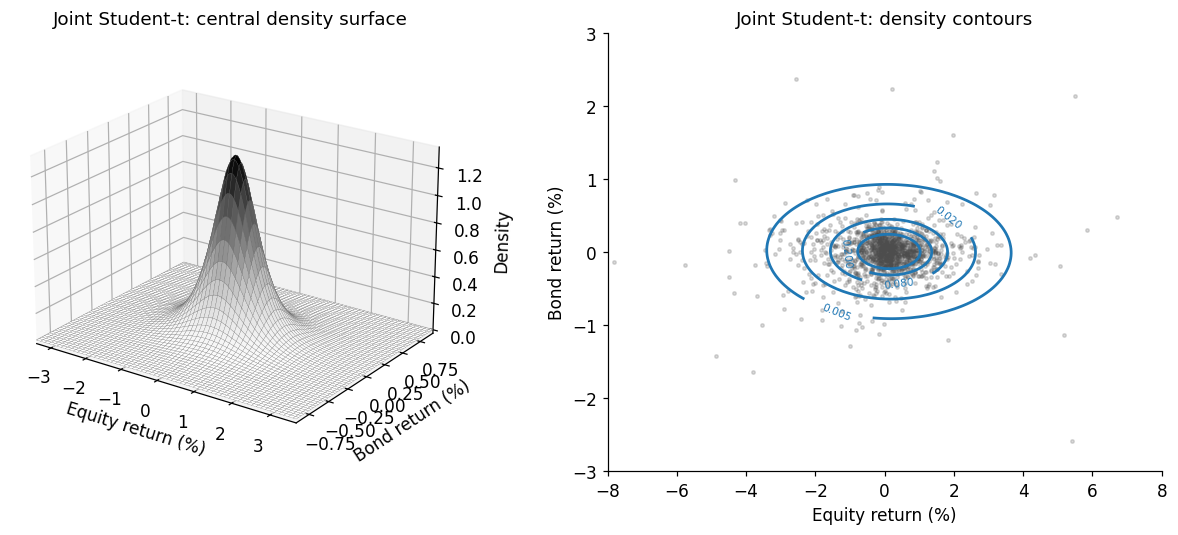

Training pairs outside contour display: 5
Surface ranges: fitted marginal 1st–99th percentiles (%): [[-3.417  3.666]
 [-0.912  0.935]]


In [17]:
display(pd.DataFrame({"Expected return (%)": selected_mean,
                      "SD (%)": np.sqrt(np.diag(selected_cov))}, index=joint_labels).round(4))
display(pd.DataFrame(selected_cov, index=joint_labels, columns=joint_labels).round(4))
print("Implied correlation:", round(selected_rho, 4))
gx, gy = np.linspace(-8, 8, 180), np.linspace(-3, 3, 180)
mx, my = np.meshgrid(gx,gy)
positions = np.stack([mx,my],axis=-1)
density = selected_density(positions)
# Zoom the surface using fitted marginal quantiles; keep the contours wide.
surface_bounds = np.array([marginal.ppf([.01, .99]) for marginal in joint_marginals])
sx, sy = np.meshgrid(np.linspace(*surface_bounds[0], 180),
                     np.linspace(*surface_bounds[1], 180))
surface_density = selected_density(np.stack([sx,sy],axis=-1))
fig = plt.figure(figsize=(12,5))
layout = fig.add_gridspec(1,2,width_ratios=[1.25,1])
surface = fig.add_subplot(layout[0,0],projection="3d")
surface.plot_surface(sx,sy,surface_density,rstride=3,cstride=3,
                     cmap="Greys",edgecolor="0.4",linewidth=.15)
surface.set(xlabel="Equity return (%)",ylabel="Bond return (%)",zlabel="Density",
            title=f"Joint {joint_family}: central density surface",
            xlim=tuple(surface_bounds[0]),ylim=tuple(surface_bounds[1]))
surface.view_init(elev=22,azim=-55)
surface.set_box_aspect((1.25,1,.8))
ax = fig.add_subplot(layout[0,1])
ax.scatter(*joint_train.T,s=5,alpha=.2,color="0.3",rasterized=True)
contours = ax.contour(mx,my,density,levels=[.005,.02,.08,.2,.4],colors="C0")
ax.clabel(contours,fontsize=7)
ax.set(title=f"Joint {joint_family}: density contours",xlabel="Equity return (%)",
       ylabel="Bond return (%)",xlim=(-8,8),ylim=(-3,3))
fig.tight_layout()
plt.show()
print("Training pairs outside contour display:",
      int(((abs(joint_train[:,0])>8)|(abs(joint_train[:,1])>3)).sum()))
print("Surface ranges: fitted marginal 1st–99th percentiles (%):", surface_bounds.round(3))


#### Marginal Distributions

The joint model also implies a univariate distribution for each component. I compare those marginal densities with the observed histograms and KDEs. These are consequences of the joint fit, not separately refitted distributions. For a joint Student-t, both marginals share its degrees of freedom, although their locations and scales differ.

Each marginal expectation is the corresponding component of the joint model's mean vector, and each marginal variance is the corresponding diagonal entry of its covariance matrix. They are the same population quantities, not separate predictions. They may differ from the standalone univariate estimates because the joint model is fitted under different restrictions. The mean and dispersion below describe these implied marginals. The earlier standalone univariate fits will be compared with them out of sample.

,Expected return (%),SD (%)
Equity (SPY),0.1244,1.4466
Bonds (AGG),0.0113,0.3772


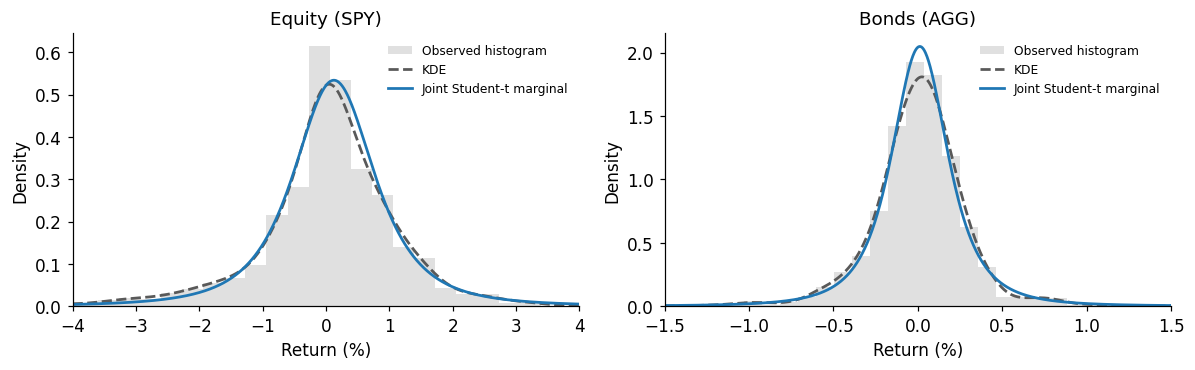

In [18]:
display(pd.DataFrame({"Expected return (%)": [d.mean() for d in joint_marginals],
                      "SD (%)": [d.std() for d in joint_marginals]},index=joint_labels).round(4))
fig, axes = plt.subplots(1,2,figsize=(11,3.5))
for j,ax in enumerate(axes):
    values = joint_train[:,j]
    width = 4 if j == 0 else 1.5
    grid = np.linspace(-width,width,1001)
    ax.hist(values,bins=60,density=True,color="0.6",alpha=.3,label="Observed histogram")
    ax.plot(grid,stats.gaussian_kde(values)(grid),color="0.35",linestyle="--",label="KDE")
    ax.plot(grid,joint_marginals[j].pdf(grid),color="C0",label=f"Joint {joint_family} marginal")
    ax.set(title=joint_labels[j],xlabel="Return (%)",ylabel="Density",xlim=(-width,width))
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


### Downside Risk

As in the univariate examples, I compare the historical and selected-model 5% VaR and ES using $L_j=-R_j$. The estimates here concern the **marginal loss of each asset**, not a single VaR or ES for the return vector. Historical estimates use the training ECDF and strict exceedances. Parametric estimates come from the selected joint model's implied marginals.

The table and loss-tail figure compare both descriptions. All estimates are frozen for the out-of-sample evaluation. Conditional risk and risk of linear combinations remain deferred.

Expected return (%)  SD (%)  \
Asset        Description                                             
Equity (SPY) Empirical                              0.0499  1.2510   
             Joint Student-t marginal               0.1244  1.4466   
Bonds (AGG)  Empirical                              0.0028  0.3377   
             Joint Student-t marginal               0.0113  0.3772   

                                       5% VaR (%)  5% ES (%)  
Asset        Description                                      
Equity (SPY) Empirical                     1.9618     3.1517  
             Joint Student-t marginal      1.5897     2.9128  
Bonds (AGG)  Empirical                     0.4465     0.7981  
             Joint Student-t marginal      0.4357     0.7808

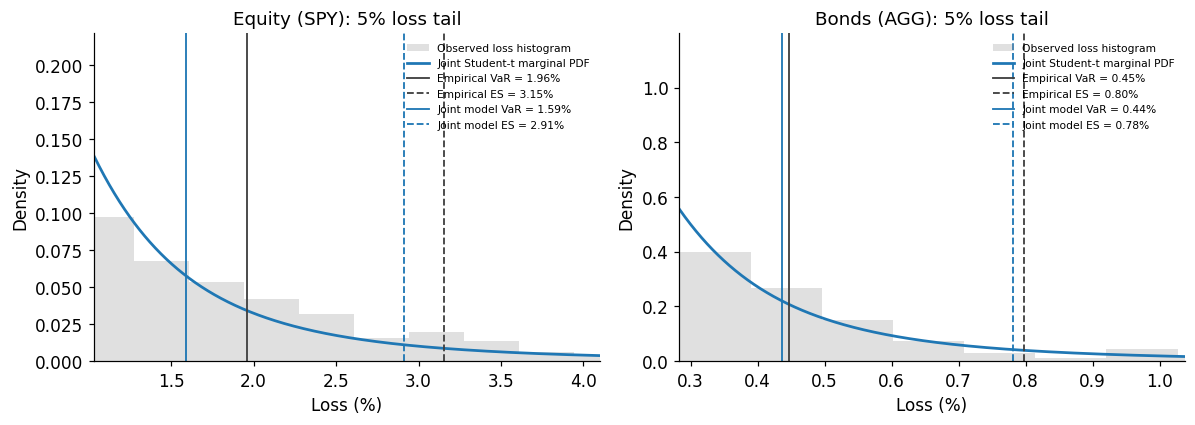

In [19]:
joint_predictions = []
for j, market in enumerate(joint_labels):
    values = joint_train[:,j]
    marginal = joint_marginals[j]
    if joint_family == "Student-t":
        implied_var = student_t_var(-selected_mean[j], np.sqrt(selected_scale[j,j]), t_fit["df"], .05)
        implied_es = student_t_es(-selected_mean[j], np.sqrt(selected_scale[j,j]), t_fit["df"], .05)
    elif joint_family == "Gaussian":
        implied_var = gaussian_var(-selected_mean[j], np.sqrt(selected_cov[j,j]), .05)
        implied_es = gaussian_es(-selected_mean[j], np.sqrt(selected_cov[j,j]), .05)
    else:
        implied_var = -marginal.ppf(.05)
        implied_es = quad(lambda loss: loss*marginal.pdf(-loss), implied_var, np.inf)[0]/.05
    np.testing.assert_allclose(implied_var, -marginal.ppf(.05))
    for method, mean, sd, var, es in [
        ("Empirical", values.mean(), values.std(ddof=0), historical_var(-values,.05), historical_es(-values,.05)),
        (f"Joint {joint_family} marginal", marginal.mean(), marginal.std(), implied_var, implied_es)]:
        joint_predictions.append({"Asset": market, "Description": method,
                                  "Expected return (%)": mean, "SD (%)": sd,
                                  "5% VaR (%)": var, "5% ES (%)": es})
joint_predictions = pd.DataFrame(joint_predictions)
display(joint_predictions.set_index(["Asset", "Description"]).round(4))
fig,axes = plt.subplots(1,2,figsize=(11,4))
for j,ax in enumerate(axes):
    losses = -joint_train[:,j]
    rows = joint_predictions[joint_predictions.Asset == joint_labels[j]].set_index("Description")
    left = rows["5% VaR (%)"].min()*.65
    right = rows["5% ES (%)"].max()*1.3
    grid = np.linspace(left,right,1001)
    ax.hist(losses,bins=60,density=True,color="0.6",alpha=.3,label="Observed loss histogram")
    ax.plot(grid,joint_marginals[j].pdf(-grid),color="C0",label=f"Joint {joint_family} marginal PDF")
    for method,color in [("Empirical","0.25"),(f"Joint {joint_family} marginal","C0")]:
        for measure,style in [("5% VaR (%)","-"),("5% ES (%)","--")]:
            value = rows.loc[method,measure]
            label = "Empirical" if method == "Empirical" else "Joint model"
            ax.axvline(value,color=color,linestyle=style,linewidth=1.2,
                       label=f"{label} {measure.split()[1]} = {value:.2f}%")
    heights,edges = np.histogram(losses,bins=60,density=True)
    visible = (edges[1:]>left)&(edges[:-1]<right)
    peak = max(heights[visible].max(),joint_marginals[j].pdf(-grid).max())
    ax.set(title=f"{joint_labels[j]}: 5% loss tail",xlabel="Loss (%)",ylabel="Density",
           xlim=(left,right),ylim=(0,peak*1.6))
    ax.legend(fontsize=7,loc="upper right")
fig.tight_layout()
plt.show()


### Out-of-Sample Evaluation

As in the univariate examples, I compare the frozen empirical and parametric predictions with 2023–2025 observations. The parametric predictions now come from the joint model. I use the same measures and show the two assets together to avoid repeating the full analysis.

#### Return, Dispersion and Distribution

The table compares predicted and realized mean, standard deviation and return-to-volatility ratio. The empirical baseline and out-of-sample observations are unchanged from the univariate examples. The figures retain their density and QQ layout.

This evaluates the joint model's implied marginals, rather than its dependence structure. Conditional distributions and linear combinations remain deferred.

Mean (%)  SD (%)  \
Asset        Description                                         
Equity (SPY) Training empirical prediction      0.0499  1.2510   
             Frozen joint Student-t marginal    0.1244  1.4466   
             Out-of-sample realization          0.0868  0.9665   
Bonds (AGG)  Training empirical prediction      0.0028  0.3377   
             Frozen joint Student-t marginal    0.0113  0.3772   
             Out-of-sample realization          0.0190  0.3751   

                                              Return / volatility  
Asset        Description                                           
Equity (SPY) Training empirical prediction                 0.0399  
             Frozen joint Student-t marginal               0.0860  
             Out-of-sample realization                     0.0898  
Bonds (AGG)  Training empirical prediction                 0.0082  
             Frozen joint Student-t marginal               0.0299  
             Out-of-sample realization                     0.0506

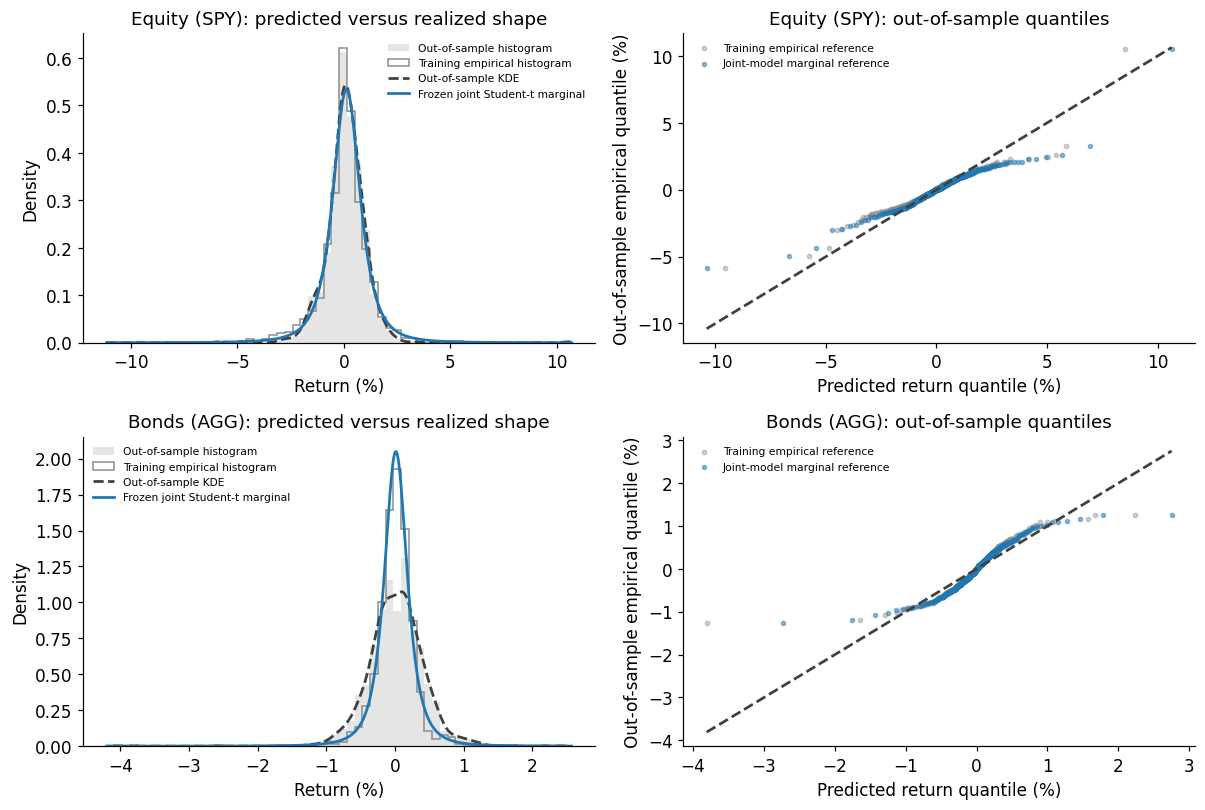

In [20]:
moment_rows = []
for j,asset in enumerate(joint_labels):
    observed = joint_test[:,j]
    for name,mu,sd in [("Training empirical prediction",joint_train[:,j].mean(),joint_train[:,j].std(ddof=0)),
                      (f"Frozen joint {joint_family} marginal",joint_marginals[j].mean(),joint_marginals[j].std()),
                      ("Out-of-sample realization",observed.mean(),observed.std(ddof=1))]:
        moment_rows.append({"Asset":asset,"Description":name,"Mean (%)":mu,"SD (%)":sd,
                            "Return / volatility":mu/sd})
display(pd.DataFrame(moment_rows).set_index(["Asset","Description"]).round(4))
fig,axes = plt.subplots(2,2,figsize=(11,7.5))
for j,asset in enumerate(joint_labels):
    train,observed,model = joint_train[:,j],joint_test[:,j],joint_marginals[j]
    low,high = min(train.min(),observed.min())-.2,max(train.max(),observed.max())+.2
    edges = np.linspace(low,high,61)
    grid = np.linspace(low,high,1201)
    ax = axes[j,0]
    ax.hist(observed,bins=edges,density=True,color="0.6",alpha=.25,label="Out-of-sample histogram")
    ax.hist(train,bins=edges,density=True,histtype="step",color="0.55",linewidth=1,label="Training empirical histogram")
    ax.plot(grid,stats.gaussian_kde(observed)(grid),color="0.25",linestyle="--",label="Out-of-sample KDE")
    ax.plot(grid,model.pdf(grid),color="C0",label=f"Frozen joint {joint_family} marginal")
    ax.set(title=f"{asset}: predicted versus realized shape",xlabel="Return (%)",ylabel="Density")
    ax.legend(fontsize=7)
    theoretical,observed_quantiles = qq_data(observed,model)
    probabilities = (np.arange(1,len(observed)+1)-.5)/len(observed)
    training_quantiles = np.array([empirical_quantile(train,q) for q in probabilities])
    ax = axes[j,1]
    ax.scatter(training_quantiles,observed_quantiles,s=8,alpha=.4,color="0.55",label="Training empirical reference")
    ax.scatter(theoretical,observed_quantiles,s=7,alpha=.5,color="C0",label="Joint-model marginal reference")
    endpoints = [min(theoretical.min(),training_quantiles.min(),observed_quantiles.min()),
                 max(theoretical.max(),training_quantiles.max(),observed_quantiles.max())]
    ax.plot(endpoints,endpoints,"--",color="0.25")
    ax.set(title=f"{asset}: out-of-sample quantiles",xlabel="Predicted return quantile (%)",
           ylabel="Out-of-sample empirical quantile (%)")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


#### Downside Risk

I use the same 5% VaR frequency and ES severity comparisons as in the univariate examples. The two method-based tables now include both assets. The empirical results are unchanged; the model results use the joint fit's marginals.

The figure shows each joint-model marginal against its observed loss tail. The empirical-tail figures already appear in the univariate examples. The ex-post tail mean uses each predicted VaR threshold, while the common test empirical ES uses the test sample's own threshold. These are marginal risk checks, not a single VaR or ES for the vector.

**Training Empirical Distribution Performance — 5% tail level, 752 observations per asset**

VaR — frequency                                         \
             Frozen threshold (%) Observed exceedances Observed rate (%)   
Asset                                                                      
Equity (SPY)                1.962             13 / 752             1.729   
Bonds (AGG)                 0.446             77 / 752            10.239   

                                      ES — severity  \
             Nominal rate (%) Frozen prediction (%)   
Asset                                                 
Equity (SPY)              5.0                 3.152   
Bonds (AGG)               5.0                 0.798   

                                                                 
             Mean above predicted VaR (%) Test empirical ES (%)  
Asset                                                            
Equity (SPY)                        3.029                 2.129  
Bonds (AGG)                         0.648                 0.793

**Frozen Joint Student-t Marginal Performance — 5% tail level, 752 observations per asset**

VaR — frequency                                         \
             Frozen threshold (%) Observed exceedances Observed rate (%)   
Asset                                                                      
Equity (SPY)                1.590             27 / 752             3.590   
Bonds (AGG)                 0.436             77 / 752            10.239   

                                      ES — severity  \
             Nominal rate (%) Frozen prediction (%)   
Asset                                                 
Equity (SPY)              5.0                 2.913   
Bonds (AGG)               5.0                 0.781   

                                                                 
             Mean above predicted VaR (%) Test empirical ES (%)  
Asset                                                            
Equity (SPY)                        2.353                 2.129  
Bonds (AGG)                         0.648                 0.793

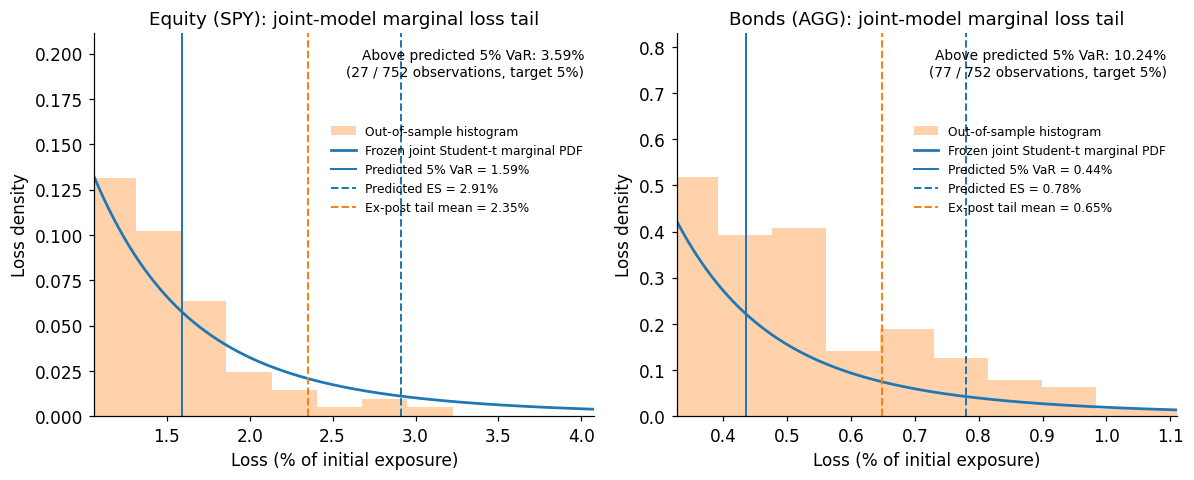

In [21]:
joint_marginal_evaluations = {}
for j,asset in enumerate(joint_labels):
    losses = -joint_test[:,j]
    evaluated = []
    for _,prediction in joint_predictions[joint_predictions.Asset == asset].iterrows():
        exceeding = losses > prediction["5% VaR (%)"]
        method = "Historical" if prediction["Description"] == "Empirical" else f"Fitted joint {joint_family} marginal"
        evaluated.append({"alpha":.05,"Method":method,
            "Frozen VaR (%)":prediction["5% VaR (%)"],"Frozen ES (%)":prediction["5% ES (%)"],
            "Observed exceedance (%)":100*exceeding.mean(),"Target exceedance (%)":5.,
            "Exceedances":int(exceeding.sum()),"Out-of-sample n":len(losses),
            "Mean loss above frozen VaR (%)":losses[exceeding].mean() if exceeding.any() else np.nan,
            "Out-of-sample empirical ES (%)":historical_es(losses,.05)})
    joint_marginal_evaluations[asset] = pd.DataFrame(evaluated)
for method,title in [("Historical","Training Empirical Distribution Performance"),
                     (f"Fitted joint {joint_family} marginal",f"Frozen Joint {joint_family} Marginal Performance")]:
    rows = pd.DataFrame({asset:table.set_index("Method").loc[method]
                         for asset,table in joint_marginal_evaluations.items()}).T
    clear_table = pd.DataFrame({
        ("VaR — frequency","Frozen threshold (%)"):rows["Frozen VaR (%)"],
        ("VaR — frequency","Observed exceedances"):rows["Exceedances"].map(lambda count:f"{int(count)} / {len(joint_test)}"),
        ("VaR — frequency","Observed rate (%)"):rows["Observed exceedance (%)"],
        ("VaR — frequency","Nominal rate (%)"):rows["Target exceedance (%)"],
        ("ES — severity","Frozen prediction (%)"):rows["Frozen ES (%)"],
        ("ES — severity","Mean above predicted VaR (%)"):rows["Mean loss above frozen VaR (%)"],
        ("ES — severity","Test empirical ES (%)"):rows["Out-of-sample empirical ES (%)"]})
    for column in clear_table.columns:
        if column[1] != "Observed exceedances":
            clear_table[column] = pd.to_numeric(clear_table[column])
    clear_table.columns = pd.MultiIndex.from_tuples(clear_table.columns)
    clear_table.index.name = "Asset"
    display(Markdown(f"**{title} — 5% tail level, {len(joint_test)} observations per asset**"))
    display(clear_table.round(3))
fig,axes = plt.subplots(1,2,figsize=(11,4.5))
for j,asset in enumerate(joint_labels):
    losses,training_losses = -joint_test[:,j],-joint_train[:,j]
    row = joint_marginal_evaluations[asset].query("Method != 'Historical'").iloc[0]
    model = joint_marginals[j]
    test_var = historical_var(losses,.05)
    left = min(row["Frozen VaR (%)"],test_var)*.75
    right = max(row["Frozen ES (%)"],row["Mean loss above frozen VaR (%)"],historical_es(losses,.05))*1.4
    grid = np.linspace(left,right,1601)
    edges = np.linspace(min(training_losses.min(),losses.min())-.2,max(training_losses.max(),losses.max())+.2,81)
    ax = axes[j]
    ax.hist(losses,bins=edges,density=True,color="C1",alpha=.35,label="Out-of-sample histogram")
    ax.plot(grid,model.pdf(-grid),color="C0",label=f"Frozen joint {joint_family} marginal PDF")
    ax.axvline(row["Frozen VaR (%)"],color="C0",linewidth=1.3,label=f'Predicted 5% VaR = {row["Frozen VaR (%)"]:.2f}%')
    ax.axvline(row["Frozen ES (%)"],color="C0",linestyle="--",linewidth=1.3,label=f'Predicted ES = {row["Frozen ES (%)"]:.2f}%')
    ax.axvline(row["Mean loss above frozen VaR (%)"],color="C1",linestyle="--",linewidth=1.3,
               label=f'Ex-post tail mean = {row["Mean loss above frozen VaR (%)"]:.2f}%')
    heights,_ = np.histogram(losses,bins=edges,density=True)
    visible = (edges[1:]>left)&(edges[:-1]<right)
    upper = max(heights[visible].max(),model.pdf(-grid).max())*1.6
    ax.set(title=f"{asset}: joint-model marginal loss tail",xlabel="Loss (% of initial exposure)",
           ylabel="Loss density",xlim=(left,right),ylim=(0,upper))
    ax.text(.98,.96,f'Above predicted 5% VaR: {row["Observed exceedance (%)"]:.2f}%\n'
            f'({int(row["Exceedances"])} / {len(losses)} observations, target 5%)',
            transform=ax.transAxes,ha="right",va="top",fontsize=9)
    ax.legend(loc="upper right",bbox_to_anchor=(1,.79),fontsize=8)
fig.tight_layout()
plt.show()
for asset,baseline in [(joint_labels[0],equity_evaluation),(joint_labels[1],bond_evaluation)]:
    columns = ["Frozen VaR (%)","Frozen ES (%)","Observed exceedance (%)",
               "Mean loss above frozen VaR (%)","Out-of-sample empirical ES (%)"]
    np.testing.assert_allclose(joint_marginal_evaluations[asset].query("Method == 'Historical'")[columns].to_numpy(),
                               baseline.query("Method == 'Historical'")[columns].to_numpy())


## 5. Comparing Univariate and Joint Models

I now compare the three descriptions on the same 2023–2025 observations: the training empirical baseline, each selected standalone univariate model, and the selected joint model's marginal distributions. All predictions were fixed at the end of 2022.

To make the comparison concise, I report absolute differences from the realized mean and standard deviation, the distance between the observed VaR exceedance rate and its 5% target, and the difference between predicted ES and the common out-of-sample empirical ES. Lower values indicate closer agreement in this realization. All differences are in percentage points.

For ES, the common reference uses each asset's test empirical 95th loss quantile. The mean above a model's own predicted VaR conditions on a different threshold, so it is not used to rank ES predictions here. The reference is itself a finite-sample estimate. These descriptive differences concern one finite evaluation period. They do not constitute a formal backtest or establish population superiority. Small advantages need not persist in another realization, and the comparison does not quantify their sampling uncertainty.

In [22]:
comparison_rows = []
for j, (asset, standalone, univariate_evaluation) in enumerate([
        (joint_labels[0], equity_model, equity_evaluation),
        (joint_labels[1], bond_model, bond_evaluation)]):
    observed = joint_test[:,j]
    observed_mean, observed_sd = observed.mean(), observed.std(ddof=1)
    test_es = historical_es(-observed,.05)
    empirical_risk = univariate_evaluation.query("Method == 'Historical'").iloc[0]
    standalone_risk = univariate_evaluation[univariate_evaluation.Method.str.startswith("Fitted")].iloc[0]
    joint_risk = joint_marginal_evaluations[asset].query("Method != 'Historical'").iloc[0]
    descriptions = [
        ("Empirical",joint_train[:,j].mean(),joint_train[:,j].std(ddof=0),empirical_risk),
        ("Standalone univariate",standalone.mean(),standalone.std(),standalone_risk),
        ("Joint-model marginal",joint_marginals[j].mean(),joint_marginals[j].std(),joint_risk)]
    for name, mean, sd, risk in descriptions:
        np.testing.assert_allclose(risk["Out-of-sample empirical ES (%)"],test_es)
        comparison_rows.append({"Asset":asset,"Description":name,
            "Mean difference (pp)":abs(mean-observed_mean),
            "SD difference (pp)":abs(sd-observed_sd),
            "VaR rate distance from 5% (pp)":abs(risk["Observed exceedance (%)"]-5),
            "ES difference (pp)":abs(risk["Frozen ES (%)"]-test_es)})
comparison = pd.DataFrame(comparison_rows).set_index(["Asset","Description"])
display(comparison.round(4))


Mean difference (pp)  SD difference (pp)  \
Asset        Description                                                       
Equity (SPY) Empirical                            0.0369              0.2845   
             Standalone univariate                0.0107              0.9259   
             Joint-model marginal                 0.0375              0.4801   
Bonds (AGG)  Empirical                            0.0162              0.0374   
             Standalone univariate                0.0065              0.0297   
             Joint-model marginal                 0.0077              0.0021   

                                    VaR rate distance from 5% (pp)  \
Asset        Description                                             
Equity (SPY) Empirical                                      3.2713   
             Standalone univariate                          1.6755   
             Joint-model marginal                           1.4096   
Bonds (AGG)  Empirical                                      5.2394   
             Standalone univariate                          5.5053   
             Joint-model marginal                           5.2394   

                                    ES difference (pp)  
Asset        Description                                
Equity (SPY) Empirical                          1.0227  
             Standalone univariate              1.0941  
             Joint-model marginal               0.7838  
Bonds (AGG)  Empirical                          0.0053  
             Standalone univariate              0.0548  
             Joint-model marginal               0.0120

The standalone univariate fits give the closest mean predictions for both assets. For equity dispersion, the empirical baseline is closest; for bond dispersion, the joint-model marginal is closest.

The joint-model marginal gives the closest equity VaR exceedance rate to 5% and the closest equity ES prediction to the common realized reference. For bonds, the empirical and joint-model VaR thresholds have the same exceedance rate, about 10.24%, so neither provides accurate 5% calibration in this period. The empirical ES prediction is closest to the bond reference.

Student-t is preferred by the in-sample likelihood criteria, but no approach performs best across all out-of-sample measures in this evaluation period. A good in-sample distributional fit does not guarantee accurate future moments or downside risk. These comparisons evaluate marginal outcomes; they do not establish the quality of the joint dependence model.

All descriptions here pool observations into fixed unconditional distributions. They do not explain when large movements occur, whether losses cluster, or whether risk changes over time. Out-of-sample discrepancies may reflect sampling variation, distributional misspecification or changing market conditions; they do not by themselves prove temporal dependence. To investigate these possibilities, the next notebooks retain the temporal ordering. Notebook 07 begins with stochastic processes and realized histories, followed by conditional-mean and conditional-variance models in Notebook 08 and their empirical application in Notebook 09.
